# Install and import

In [ ]:
!pip install torch-geometric


In [ ]:
!pip install umap-learn

In [2]:
import pandas as pd
import numpy as np

from datetime import timedelta

import torch
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, SAGEConv, GATv2Conv
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve


import umap.umap_ as umap

import matplotlib.pyplot as plt
from sklearn.datasets import load_iris


# Data - 5elem

## UNSW1

In [3]:
data_unsw1 = pd.read_csv('/content/UNSW-NB15_1.csv', dtype={'sport': object, 'dsport': object}, low_memory=False)

columnas = [
    "srcip", "sport", "dstip", "dsport", "proto", "state", "dur", "sbytes", "dbytes", "sttl",
    "dttl", "sloss", "dloss", "service", "sload", "dload", "spkts", "dpkts", "swin", "dwin",
    "stcpb", "dtcpb", "smeansz", "dmeansz", "trans_depth", "res_bdy_len", "sjit", "djit",
    "stime", "ltime", "sintpkt", "dintpkt", "tcprtt", "synack", "ackdat", "is_sm_ips_ports",
    "ct_state_ttl", "ct_flw_http_mthd", "is_ftp_login", "ct_ftp_cmd", "ct_srv_src", "ct_srv_dst",
    "ct_dst_ltm", "ct_src_ltm", "ct_src_dport_ltm", "ct_dst_sport_ltm", "ct_dst_src_ltm",
    "attack_cat", "label"
]

data_unsw1.columns = columnas


# Convert 'stime' and 'ltime' to datetime format
data_unsw1['stime'] = pd.to_datetime(data_unsw1['stime'], unit='s')
data_unsw1['ltime'] = pd.to_datetime(data_unsw1['ltime'], unit='s')


# Filter connections lasting less than a second
filtered_unsw1 = data_unsw1[(data_unsw1['dur']>0) & (data_unsw1['dur'] <= 1)]


# Filter connections from the first 110 minutes (that's where there are malicios connections)
# And select columns of interest
start_time = data_unsw1['stime'].min()
end_time = start_time + timedelta(minutes=110)

unsw1_sub = filtered_unsw1[(filtered_unsw1['stime'] >= start_time) & (filtered_unsw1['stime'] < end_time)][['srcip','sport','dstip','dsport','proto','dur','sbytes','dbytes','spkts','dpkts','stime','ltime','label']].drop_duplicates()

# Drop rows with NaN values (i.e., missing ports)
unsw1_sub.replace('-', pd.NA, inplace=True)
unsw1 = unsw1_sub.dropna()

In [ ]:
data_unsw1.duplicated().sum()

59213

In [ ]:
unsw1_sub_NOdrop = filtered_unsw1[(filtered_unsw1['stime'] >= start_time) & (filtered_unsw1['stime'] < end_time)][['srcip','sport','dstip','dsport','proto','dur','sbytes','dbytes','spkts','dpkts','stime','ltime','label']]
unsw1_sub_NOdrop.duplicated().sum()

19

In [ ]:
unsw1_sub_drop = filtered_unsw1[(filtered_unsw1['stime'] >= start_time) & (filtered_unsw1['stime'] < end_time)][['srcip','sport','dstip','dsport','proto','dur','sbytes','dbytes','spkts','dpkts','stime','ltime','label']].drop_duplicates()
unsw1_sub_drop.duplicated().sum()

0

In [ ]:
unsw1.duplicated().sum()

0

In [ ]:
# from sklearn.preprocessing import MinMaxScaler

# # Seleccionar las características a normalizar
# features_to_normalize = ['dur', 'sbytes', 'dbytes', 'spkts', 'dpkts']

# # Crear un objeto MinMaxScaler
# scaler = MinMaxScaler()

# # Ajustar y transformar las características
# unsw1[features_to_normalize] = scaler.fit_transform(unsw1[features_to_normalize])

# # Verificar resultados
# print(unsw1[features_to_normalize].describe())

Text(0, 0.5, 'Frecuencia')

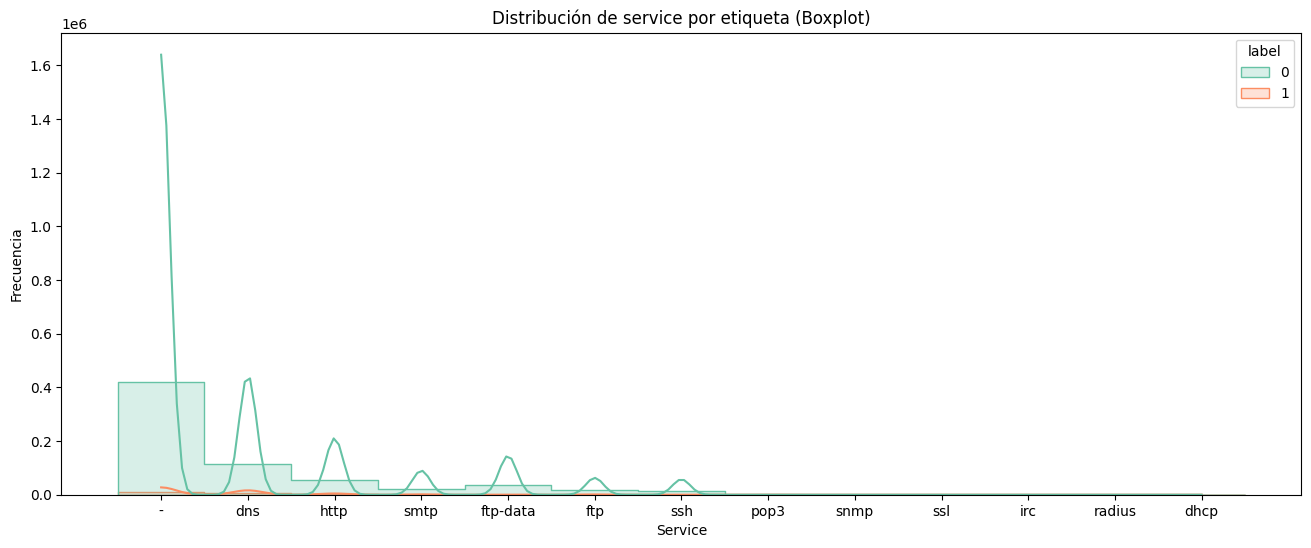

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 6))
sns.histplot(data=data_unsw1, x='service', hue='label', kde=True, palette='Set2', element='step')
plt.title(f'Distribución de service por etiqueta (Boxplot)')
plt.xlabel('Service')
plt.ylabel('Frecuencia')

<ipython-input-60-df355e9cd2bb>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=snapshot_data, x='label', y=feature, palette='Set2')


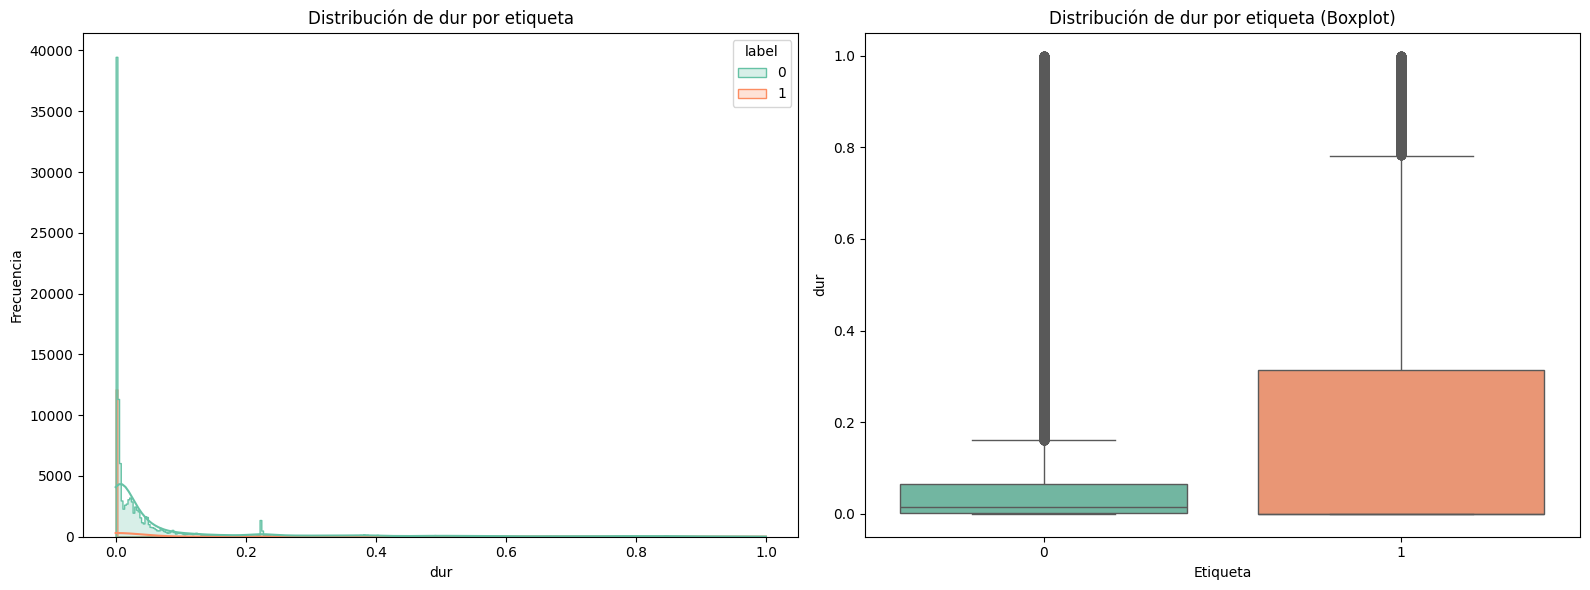

<ipython-input-60-df355e9cd2bb>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=snapshot_data, x='label', y=feature, palette='Set2')


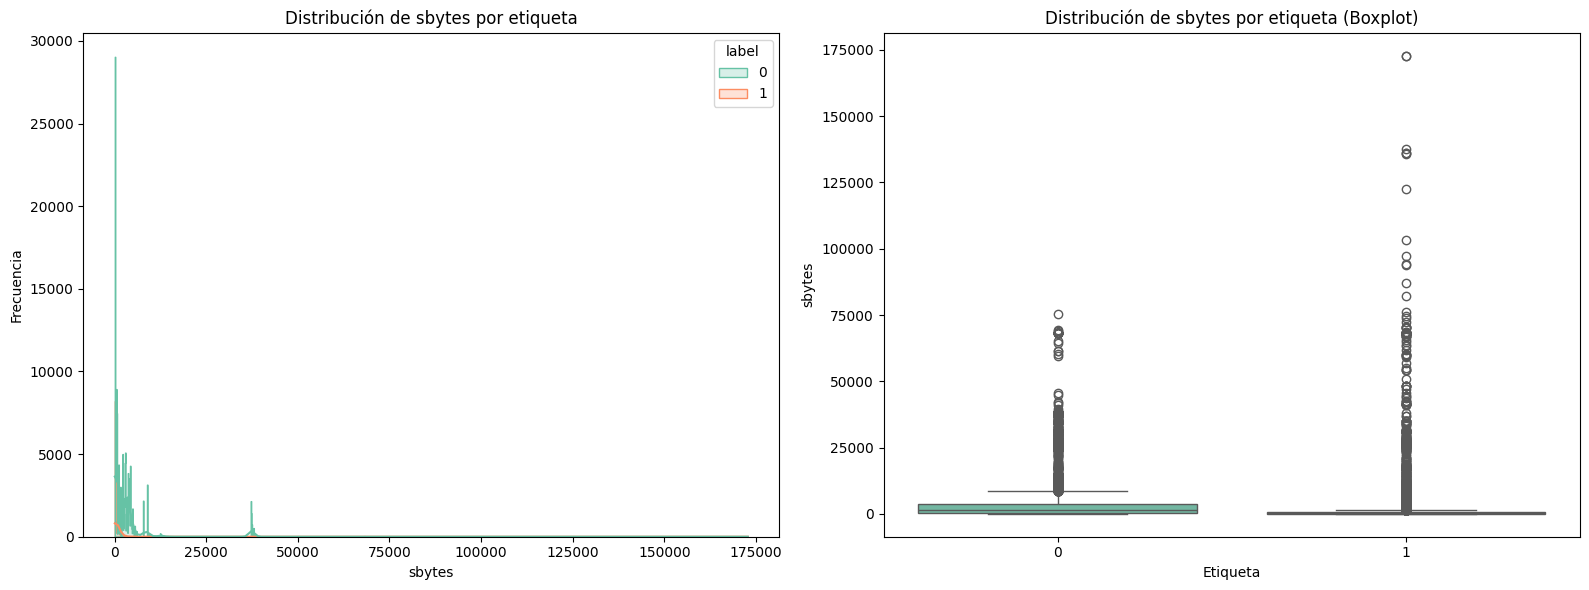

<ipython-input-60-df355e9cd2bb>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=snapshot_data, x='label', y=feature, palette='Set2')


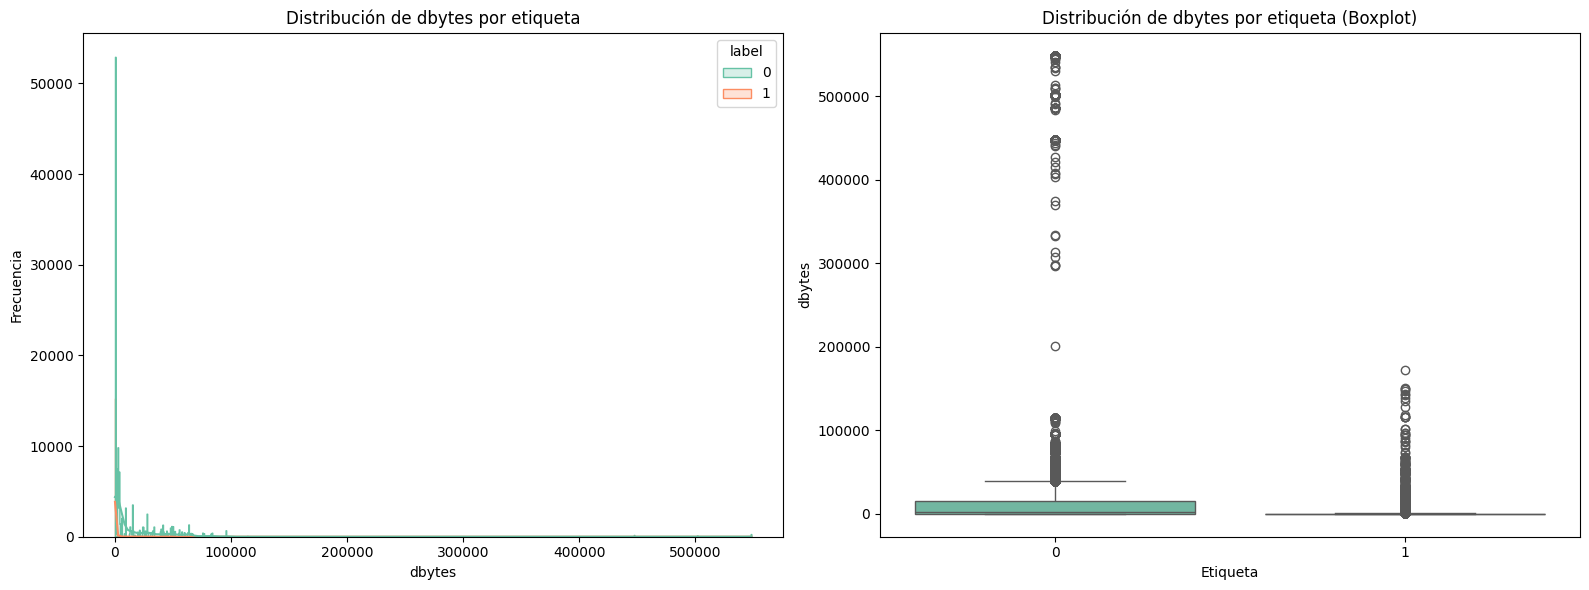

<ipython-input-60-df355e9cd2bb>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=snapshot_data, x='label', y=feature, palette='Set2')


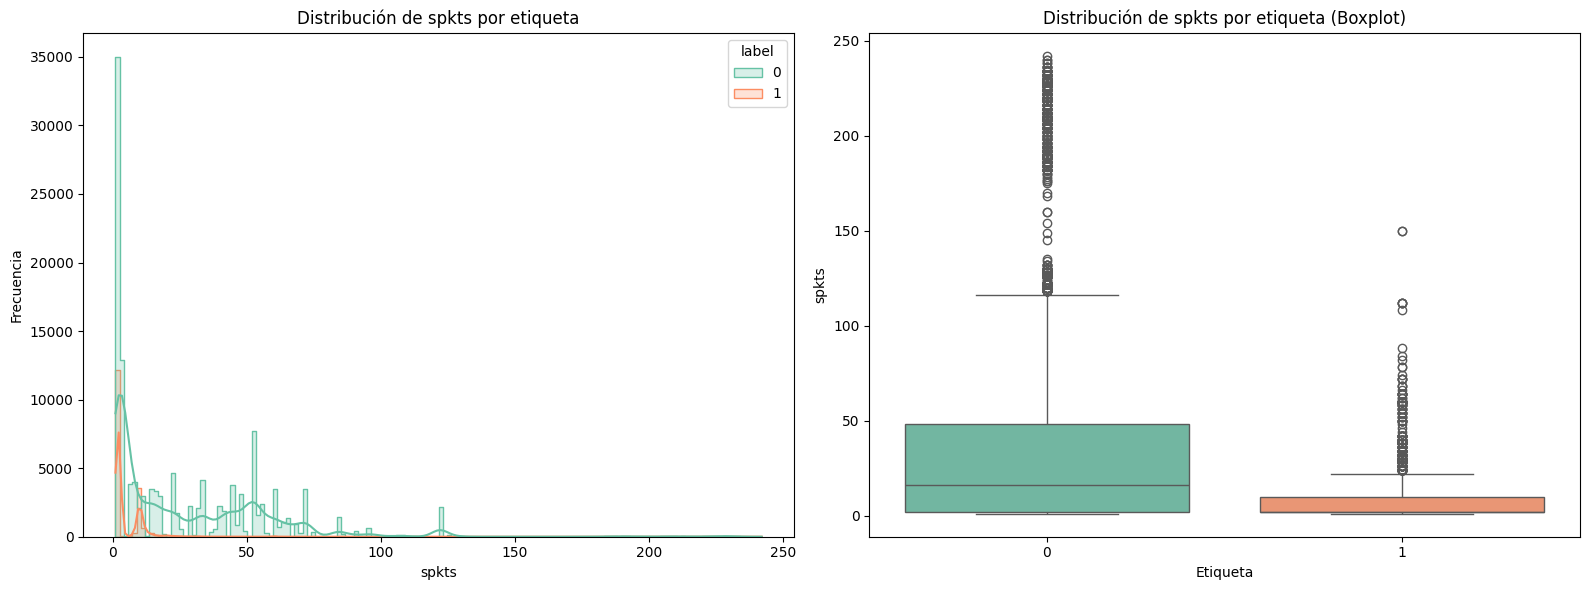

<ipython-input-60-df355e9cd2bb>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=snapshot_data, x='label', y=feature, palette='Set2')


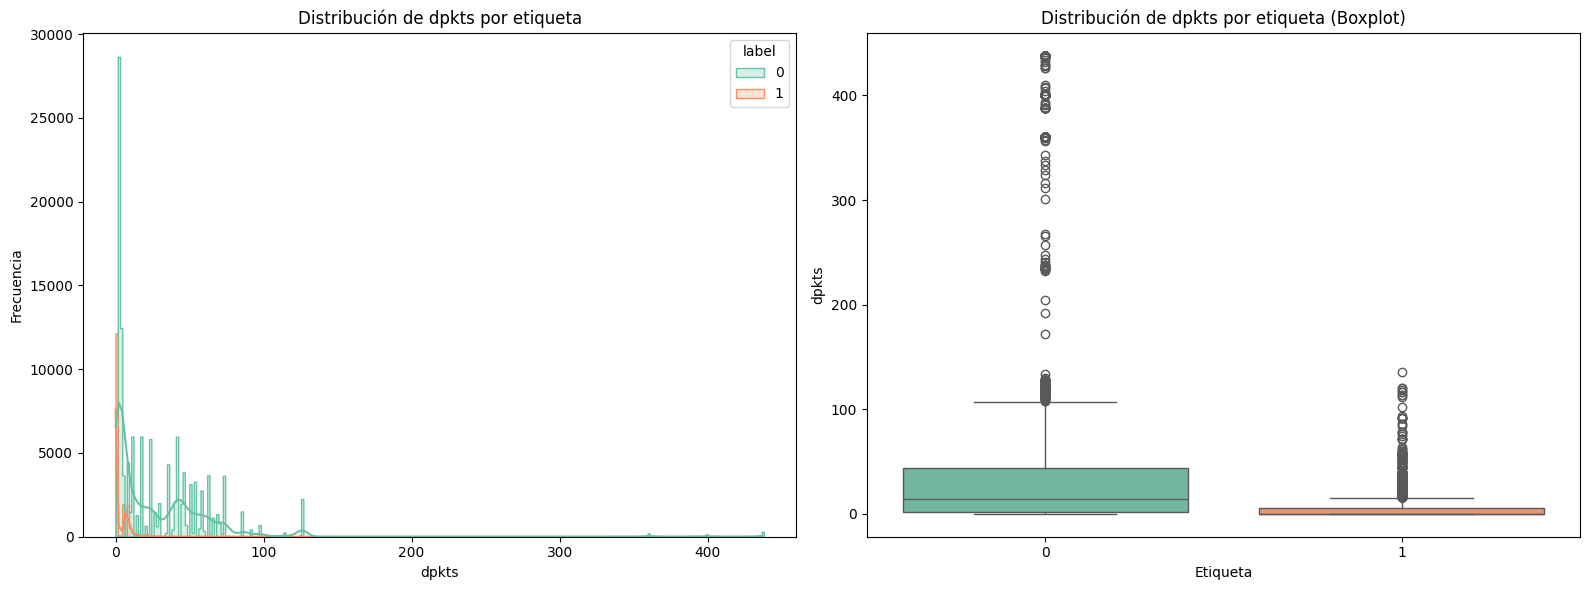

Resumen estadístico de características por etiqueta:
label                     0              1
dur    count  129638.000000   17583.000000
       mean        0.095572       0.175556
       std         0.191167       0.292284
       min         0.000001       0.000001
       25%         0.001133       0.000006
       50%         0.015694       0.000011
       75%         0.065296       0.313004
       max         0.999911       0.999796
sbytes count  129638.000000   17583.000000
       mean     3707.852713    1205.460957
       std      7646.479198    6260.903199
       min        52.000000      60.000000
       25%       264.000000     114.000000
       50%      1540.000000     200.000000
       75%      3614.000000     662.000000
       max     75496.000000  172777.000000
dbytes count  129638.000000   17583.000000
       mean    15315.718192     925.854291
       std     41318.436394    6325.192980
       min         0.000000       0.000000
       25%       178.000000       0.000000
 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Crear un DataFrame temporal para análisis
snapshot_data = unsw1.copy()  # Asegúrate de usar el conjunto preprocesado `unsw1`

# Seleccionar columnas relevantes
features_to_plot = ['dur', 'sbytes', 'dbytes', 'spkts', 'dpkts']  # Características más importantes
labels = snapshot_data['label']  # Etiqueta

# Crear histogramas y boxplots por característica y etiqueta
for feature in features_to_plot:
    plt.figure(figsize=(16, 6))

    # Histograma
    plt.subplot(1, 2, 1)
    sns.histplot(data=snapshot_data, x=feature, hue='label', kde=True, palette='Set2', element='step')
    plt.title(f'Distribución de {feature} por etiqueta')
    plt.xlabel(feature)
    plt.ylabel('Frecuencia')

    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(data=snapshot_data, x='label', y=feature, palette='Set2')
    plt.title(f'Distribución de {feature} por etiqueta (Boxplot)')
    plt.xlabel('Etiqueta')
    plt.ylabel(feature)

    plt.tight_layout()
    plt.show()

# Resumen estadístico
print("Resumen estadístico de características por etiqueta:")
summary_stats = snapshot_data.groupby('label')[features_to_plot].describe().transpose()
print(summary_stats)


### Option 1: Nodes = (ip, port)

In [ ]:
edge_indices = []
edge_features = []
labels = []
edge_weights = []
node_features = []

min_start_time = unsw1['stime'].min()
max_end_time = unsw1['ltime'].max()


interval_snapshot = timedelta(minutes=3) # Snapshots every 3 minutes

start_time = min_start_time
end_time = start_time  + interval_snapshot


while start_time  < max_end_time:
    snapshot_data = unsw1[(unsw1['stime'] >= start_time ) & (unsw1['stime'] < end_time)]

    src = snapshot_data[['srcip', 'sport']].copy()
    src.rename(columns={'srcip':'ip','sport':'port'}, inplace=True)

    dst = snapshot_data[['dstip', 'dsport']].copy()
    dst.rename(columns={'dstip':'ip','dsport':'port'}, inplace=True)

    unique_pairs = pd.concat([src,dst]).drop_duplicates()
    unique_pairs['ip'] = unique_pairs['ip'].str.strip()  # Limpia espacios en 'ip'
    unique_pairs['port'] = unique_pairs['port'].astype(str).str.strip()  # Asegura que 'port' es cadena
    unique_pairs = unique_pairs.drop_duplicates(subset=['ip', 'port'])

    unique_pairs['pair_id'] = unique_pairs.groupby(['ip','port']).ngroup()
    unique_pairs = unique_pairs.sort_values('pair_id').set_index('pair_id').reset_index()
    unique_pairs['pairs'] = unique_pairs.apply(lambda x: str(x['ip']) + ',' + str(x['port']), axis=1)

    pair_to_index = {pair: idx for idx, pair in zip(unique_pairs['pair_id'], unique_pairs['pairs'])}

    src_features = snapshot_data.groupby(['srcip', 'sport']).agg({        # AGREGO puerto, pero no se como considerar el protocolo
        'spkts': 'mean',
        'sbytes': 'mean'
    }).reset_index()
    src_features['src_pairs'] = src_features.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']), axis=1)
    src_features = src_features.set_index('src_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    dst_features = snapshot_data.groupby(['dstip', 'dsport']).agg({        # AGREGO puerto, pero no se como considerar el protocolo
        'dpkts': 'mean',
        'dbytes': 'mean'
    }).reset_index()
    dst_features['dst_pairs'] = dst_features.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']), axis=1)
    dst_features = dst_features.set_index('dst_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    nodes_features = pd.merge(src_features, dst_features, left_on=['src_pairs'], right_on=['dst_pairs'], how='outer')
    nodes_features = nodes_features[['spkts', 'sbytes', 'dpkts', 'dbytes']]
    nodes_features_tensor = torch.tensor(nodes_features.values, dtype=torch.float)


    edge_attr = snapshot_data.groupby(['srcip', 'sport', 'proto', 'dstip', 'dsport']).agg({
        'dur': 'mean',
        #'sbytes': 'mean',
        #'dbytes': 'mean',
        #'spkts': 'mean',
        #'dpkts': 'mean',
        'label': 'max'
    }).reset_index()
    edge_attr['src_pairs'] = edge_attr.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']), axis=1)
    edge_attr['dst_pairs'] = edge_attr.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']), axis=1)

    edge_index = torch.tensor([[pair_to_index[src], pair_to_index[dst]] for src, dst in zip(edge_attr['src_pairs'], edge_attr['dst_pairs'])], dtype=torch.long).t().contiguous()

    #edge_features_tensor = torch.tensor(edge_attr[['dur', 'sbytes', 'dbytes', 'spkts', 'dpkts']].values, dtype=torch.float)
    edge_features_tensor = torch.tensor(edge_attr[['dur']].values, dtype=torch.float)
    edge_labels_tensor = torch.tensor(edge_attr['label'].values, dtype=torch.long)

    # Añadir el snapshot a las listas
    edge_indices.append(edge_index)
    edge_features.append(edge_features_tensor)
    labels.append(edge_labels_tensor)
    edge_weights.append(torch.ones(len(edge_index[0]), dtype=torch.float))
    #node_features.append(torch.ones(len(unique_pairs),1, dtype=torch.float))
    node_features.append(nodes_features_tensor)

    # Avanzar al siguiente intervalo de tiempo
    start_time = end_time
    end_time += interval_snapshot

#graph_snapshots = {i: Data(x=node_features_pad, edge_index=edge_indices[i], edge_attr=edge_features[i], y=labels[i]) for i in range(len(edge_indices)-1)}
torch_geo_graphs_unsw1 = {i: Data(x=node_features[i], edge_index=edge_indices[i], edge_attr=edge_features[i], y=labels[i]) for i in range(len(edge_indices)-1)}

### Option 2: Nodes = (ip,port,proto) - Features de los edges

In [ ]:
edge_indices = []
edge_features = []
labels = []
edge_weights = []
node_features = []

min_start_time = unsw1['stime'].min()
max_end_time = unsw1['ltime'].max()


interval_snapshot = timedelta(minutes=3)
start_time = min_start_time
end_time = start_time  + interval_snapshot


while start_time  < max_end_time:
    snapshot_data = unsw1[(unsw1['stime'] >= start_time ) & (unsw1['stime'] < end_time)]

    src = snapshot_data[['srcip', 'sport','proto']].copy()
    src.rename(columns={'srcip':'ip','sport':'port'}, inplace=True)

    dst = snapshot_data[['dstip', 'dsport','proto']].copy()
    dst.rename(columns={'dstip':'ip','dsport':'port'}, inplace=True)

    unique_pairs = pd.concat([src,dst]).drop_duplicates()
    unique_pairs['ip'] = unique_pairs['ip'].str.strip()
    unique_pairs['port'] = unique_pairs['port'].astype(str).str.strip()
    unique_pairs = unique_pairs.drop_duplicates(subset=['ip', 'port', 'proto'])

    unique_pairs['pair_id'] = unique_pairs.groupby(['ip','port','proto']).ngroup()
    unique_pairs = unique_pairs.sort_values('pair_id').set_index('pair_id').reset_index()
    unique_pairs['pairs'] = unique_pairs.apply(lambda x: str(x['ip']) + ',' + str(x['port']) + ',' + str(x['proto']), axis=1)

    pair_to_index = {pair: idx for idx, pair in zip(unique_pairs['pair_id'], unique_pairs['pairs'])}

    # src_features = snapshot_data.groupby(['srcip', 'sport', 'proto']).agg({
    #     'spkts': 'mean',
    #     'sbytes': 'mean'
    # }).reset_index()
    # src_features['src_pairs'] = src_features.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
    # src_features = src_features.set_index('src_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    # dst_features = snapshot_data.groupby(['dstip', 'dsport', 'proto']).agg({
    #     'dpkts': 'mean',
    #     'dbytes': 'mean'
    # }).reset_index()
    # dst_features['dst_pairs'] = dst_features.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)
    # dst_features = dst_features.set_index('dst_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    # nodes_features = pd.merge(src_features, dst_features, left_on=['src_pairs'], right_on=['dst_pairs'], how='outer')
    # nodes_features = nodes_features[['spkts', 'sbytes', 'dpkts', 'dbytes']]
    # nodes_features_tensor = torch.tensor(nodes_features.values, dtype=torch.float)

    edge_attr = snapshot_data.groupby(['srcip', 'sport', 'proto', 'dstip', 'dsport']).agg({
        'dur': 'mean',
        'sbytes': 'mean',
        'dbytes': 'mean',
        'spkts': 'mean',
        'dpkts': 'mean',
        'label': 'max'
    }).reset_index()
    edge_attr['src_pairs'] = edge_attr.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
    edge_attr['dst_pairs'] = edge_attr.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)

    edge_index = torch.tensor([[pair_to_index[src], pair_to_index[dst]] for src, dst in zip(edge_attr['src_pairs'], edge_attr['dst_pairs'])], dtype=torch.long).t().contiguous()

    edge_features_tensor = torch.tensor(edge_attr[['dur', 'sbytes', 'dbytes', 'spkts', 'dpkts']].values, dtype=torch.float)
    #edge_features_tensor = torch.tensor(edge_attr[['dur']].values, dtype=torch.float)
    edge_labels_tensor = torch.tensor(edge_attr['label'].values, dtype=torch.long)

    # Añadir el snapshot a las listas
    edge_indices.append(edge_index)
    edge_features.append(edge_features_tensor)
    labels.append(edge_labels_tensor)
    edge_weights.append(torch.ones(len(edge_index[0]), dtype=torch.float))
    node_features.append(torch.ones(len(unique_pairs),1, dtype=torch.float))
    #node_features.append(nodes_features_tensor)

    # Avanzar al siguiente intervalo de tiempo
    start_time = end_time
    end_time += interval_snapshot


torch_geo_graphs_unsw1_proto = {i: Data(x=node_features[i], edge_index=edge_indices[i], edge_attr=edge_features[i], y=labels[i]) for i in range(len(edge_indices)-1)}

In [ ]:
torch_geo_graphs_unsw1_proto

{0: Data(x=[4451, 1], edge_index=[2, 3279], edge_attr=[3279, 5], y=[3279]),
 1: Data(x=[4843, 1], edge_index=[2, 3532], edge_attr=[3532, 5], y=[3532]),
 2: Data(x=[4764, 1], edge_index=[2, 3570], edge_attr=[3570, 5], y=[3570]),
 3: Data(x=[5494, 1], edge_index=[2, 4187], edge_attr=[4187, 5], y=[4187]),
 4: Data(x=[5688, 1], edge_index=[2, 4376], edge_attr=[4376, 5], y=[4376]),
 5: Data(x=[4931, 1], edge_index=[2, 3554], edge_attr=[3554, 5], y=[3554]),
 6: Data(x=[5456, 1], edge_index=[2, 3971], edge_attr=[3971, 5], y=[3971]),
 7: Data(x=[5042, 1], edge_index=[2, 3605], edge_attr=[3605, 5], y=[3605]),
 8: Data(x=[4898, 1], edge_index=[2, 3414], edge_attr=[3414, 5], y=[3414]),
 9: Data(x=[4794, 1], edge_index=[2, 3300], edge_attr=[3300, 5], y=[3300]),
 10: Data(x=[4771, 1], edge_index=[2, 3333], edge_attr=[3333, 5], y=[3333]),
 11: Data(x=[4908, 1], edge_index=[2, 3379], edge_attr=[3379, 5], y=[3379]),
 12: Data(x=[5495, 1], edge_index=[2, 3664], edge_attr=[3664, 5], y=[3664]),
 13: Data

### Option 2': Nodes = (ip, port, proto) - Features de los nodos

In [94]:
start_time = data_unsw1['stime'].min()
end_time = start_time + timedelta(minutes=110)

unsw1_sub = filtered_unsw1[(filtered_unsw1['stime'] >= start_time) & (filtered_unsw1['stime'] < end_time)][['srcip','sport','dstip','dsport','proto','dur','sbytes','dbytes','spkts','dpkts','stime','ltime','label']].drop_duplicates()

# Drop rows with NaN values (i.e., missing ports)
unsw1_sub.replace('-', pd.NA, inplace=True)
unsw1 = unsw1_sub.dropna()

In [95]:
edge_indices = []
edge_features = []
labels = []
edge_weights = []
node_features = []

min_start_time = unsw1['stime'].min()
max_end_time = unsw1['ltime'].max()


interval_snapshot = timedelta(minutes=3)
start_time = min_start_time
end_time = start_time  + interval_snapshot


while start_time  < max_end_time:
    snapshot_data = unsw1[(unsw1['stime'] >= start_time ) & (unsw1['stime'] < end_time)]

    src = snapshot_data[['srcip', 'sport','proto']].copy()
    src.rename(columns={'srcip':'ip','sport':'port'}, inplace=True)

    dst = snapshot_data[['dstip', 'dsport','proto']].copy()
    dst.rename(columns={'dstip':'ip','dsport':'port'}, inplace=True)

    unique_pairs = pd.concat([src,dst]).drop_duplicates()
    unique_pairs['ip'] = unique_pairs['ip'].str.strip()
    unique_pairs['port'] = unique_pairs['port'].astype(str).str.strip()
    unique_pairs = unique_pairs.drop_duplicates(subset=['ip', 'port', 'proto'])

    unique_pairs['pair_id'] = unique_pairs.groupby(['ip','port','proto']).ngroup()
    unique_pairs = unique_pairs.sort_values('pair_id').set_index('pair_id').reset_index()
    unique_pairs['pairs'] = unique_pairs.apply(lambda x: str(x['ip']) + ',' + str(x['port']) + ',' + str(x['proto']), axis=1)

    pair_to_index = {pair: idx for idx, pair in zip(unique_pairs['pair_id'], unique_pairs['pairs'])}

    src_features = snapshot_data.groupby(['srcip', 'sport', 'proto']).agg({
        'spkts': 'mean',
        'sbytes': 'mean'
    }).reset_index()
    src_features['src_pairs'] = src_features.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
    src_features = src_features.set_index('src_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    dst_features = snapshot_data.groupby(['dstip', 'dsport', 'proto']).agg({
        'dpkts': 'mean',
        'dbytes': 'mean'
    }).reset_index()
    dst_features['dst_pairs'] = dst_features.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)
    dst_features = dst_features.set_index('dst_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    nodes_features = pd.merge(src_features, dst_features, left_on=['src_pairs'], right_on=['dst_pairs'], how='outer')
    nodes_features = nodes_features[['spkts', 'sbytes', 'dpkts', 'dbytes']]
    nodes_features_tensor = torch.tensor(nodes_features.values, dtype=torch.float)


    edge_attr = snapshot_data.groupby(['srcip', 'sport', 'proto', 'dstip', 'dsport']).agg({
        'dur': 'mean',
        #'sbytes': 'mean',
        #'dbytes': 'mean',
        #'spkts': 'mean',
        #'dpkts': 'mean',
        'label': 'max'
    }).reset_index()
    edge_attr['src_pairs'] = edge_attr.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
    edge_attr['dst_pairs'] = edge_attr.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)

    edge_index = torch.tensor([[pair_to_index[src], pair_to_index[dst]] for src, dst in zip(edge_attr['src_pairs'], edge_attr['dst_pairs'])], dtype=torch.long).t().contiguous()

    #edge_features_tensor = torch.tensor(edge_attr[['dur', 'sbytes', 'dbytes', 'spkts', 'dpkts']].values, dtype=torch.float)
    edge_features_tensor = torch.tensor(edge_attr[['dur']].values, dtype=torch.float)
    edge_labels_tensor = torch.tensor(edge_attr['label'].values, dtype=torch.long)

    # Añadir el snapshot a las listas
    edge_indices.append(edge_index)
    edge_features.append(edge_features_tensor)
    labels.append(edge_labels_tensor)
    edge_weights.append(torch.ones(len(edge_index[0]), dtype=torch.float))
    #node_features.append(torch.ones(len(unique_pairs),1, dtype=torch.float))
    node_features.append(nodes_features_tensor)

    # Avanzar al siguiente intervalo de tiempo
    start_time = end_time
    end_time += interval_snapshot


torch_geo_graphs_unsw1_proto = {i: Data(x=node_features[i], edge_index=edge_indices[i], edge_attr=edge_features[i], y=labels[i]) for i in range(len(edge_indices)-1)}

In [ ]:
div_prop=0
for i in range(len(torch_geo_graphs_unsw1_proto)):
  sum_norm=0
  sum_bot=0
  for j in range(len(torch_geo_graphs_unsw1_proto[i].y)):
    if torch_geo_graphs_unsw1_proto[i].y[j]==0:
      sum_norm+=1
    else:
      sum_bot+=1
  div_prop+= (sum_norm/sum_bot)
  print(i,sum_norm,sum_bot,sum_norm/sum_bot)

print(div_prop/36)

0 3117 162 19.24074074074074
1 3235 297 10.892255892255893
2 3386 184 18.402173913043477
3 4119 68 60.5735294117647
4 4247 129 32.92248062015504
5 3371 183 18.420765027322403
6 3795 176 21.5625
7 3343 262 12.759541984732824
8 3239 175 18.50857142857143
9 3093 207 14.942028985507246
10 3149 184 17.11413043478261
11 3142 237 13.257383966244726
12 3443 221 15.57918552036199
13 3422 210 16.295238095238094
14 3621 190 19.057894736842105
15 3558 197 18.060913705583758
16 3362 170 19.776470588235295
17 3406 177 19.242937853107346
18 3233 339 9.536873156342184
19 3239 178 18.196629213483146
20 3191 236 13.521186440677965
21 3300 198 16.666666666666668
22 3337 168 19.863095238095237
23 3311 169 19.59171597633136
24 3300 178 18.53932584269663
25 3403 183 18.595628415300546
26 3087 226 13.65929203539823
27 3133 205 15.282926829268293
28 3174 187 16.97326203208556
29 3198 210 15.228571428571428
30 3377 176 19.1875
31 3758 132 28.46969696969697
32 3288 103 31.92233009708738
33 3318 173 19.179190751

In [ ]:
# Esta comparacion no es justa, porque los nodos y edges cambian de un snapshot a otro

pairs1 = set(tuple(pair) for pair in torch_geo_graphs_unsw1_proto[1].edge_index.T.tolist())

for i in range(len(torch_geo_graphs_unsw1_proto)):
  pairs2 = set(tuple(pair) for pair in torch_geo_graphs_unsw1_proto[i].edge_index.T.tolist())
  print(i,len(pairs1.intersection(pairs2)),len(pairs1.intersection(pairs2))/len(torch_geo_graphs_unsw1_proto[i].y))

#### Breve exploracion del preprocesamiento

In [ ]:
edge_indices = []
edge_features = []
labels = []
edge_weights = []
node_features = []

node_features_orig = []
pair_to_index_list = []
src_features_list = []
dst_features_list = []
edge_attr_list = []

min_start_time = unsw1['stime'].min()
max_end_time = unsw1['ltime'].max()


interval_snapshot = timedelta(minutes=3)
start_time = min_start_time
end_time = start_time  + interval_snapshot


while start_time  < max_end_time:
    snapshot_data = unsw1[(unsw1['stime'] >= start_time ) & (unsw1['stime'] < end_time)]

    src = snapshot_data[['srcip', 'sport','proto']].copy()
    src.rename(columns={'srcip':'ip','sport':'port'}, inplace=True)

    dst = snapshot_data[['dstip', 'dsport','proto']].copy()
    dst.rename(columns={'dstip':'ip','dsport':'port'}, inplace=True)

    unique_pairs = pd.concat([src,dst]).drop_duplicates()
    unique_pairs['ip'] = unique_pairs['ip'].str.strip()
    unique_pairs['port'] = unique_pairs['port'].astype(str).str.strip()
    unique_pairs = unique_pairs.drop_duplicates(subset=['ip', 'port', 'proto'])

    unique_pairs['pair_id'] = unique_pairs.groupby(['ip','port','proto']).ngroup()
    unique_pairs = unique_pairs.sort_values('pair_id').set_index('pair_id').reset_index()
    unique_pairs['pairs'] = unique_pairs.apply(lambda x: str(x['ip']) + ',' + str(x['port']) + ',' + str(x['proto']), axis=1)

    pair_to_index = {pair: idx for idx, pair in zip(unique_pairs['pair_id'], unique_pairs['pairs'])}

    src_features = snapshot_data.groupby(['srcip', 'sport', 'proto']).agg({
        'spkts': 'mean',
        'sbytes': 'mean'
    }).reset_index()
    src_features['src_pairs'] = src_features.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
    src_features = src_features.set_index('src_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    dst_features = snapshot_data.groupby(['dstip', 'dsport', 'proto']).agg({
        'dpkts': 'mean',
        'dbytes': 'mean'
    }).reset_index()
    dst_features['dst_pairs'] = dst_features.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)
    dst_features = dst_features.set_index('dst_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    nodes_features_orig = pd.merge(src_features, dst_features, left_on=['src_pairs'], right_on=['dst_pairs'], how='outer')

    nodes_features = nodes_features_orig[['spkts', 'sbytes', 'dpkts', 'dbytes']]
    nodes_features_tensor = torch.tensor(nodes_features.values, dtype=torch.float)


    edge_attr = snapshot_data.groupby(['srcip', 'sport', 'proto', 'dstip', 'dsport']).agg({
        'dur': 'mean',
        #'sbytes': 'mean',
        #'dbytes': 'mean',
        #'spkts': 'mean',
        #'dpkts': 'mean',
        'label': 'max'
    }).reset_index()
    edge_attr['src_pairs'] = edge_attr.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
    edge_attr['dst_pairs'] = edge_attr.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)

    edge_index = torch.tensor([[pair_to_index[src], pair_to_index[dst]] for src, dst in zip(edge_attr['src_pairs'], edge_attr['dst_pairs'])], dtype=torch.long).t().contiguous()

    #edge_features_tensor = torch.tensor(edge_attr[['dur', 'sbytes', 'dbytes', 'spkts', 'dpkts']].values, dtype=torch.float)
    edge_features_tensor = torch.tensor(edge_attr[['dur']].values, dtype=torch.float)
    edge_labels_tensor = torch.tensor(edge_attr['label'].values, dtype=torch.long)

    # Añadir el snapshot a las listas
    edge_indices.append(edge_index)
    edge_features.append(edge_features_tensor)
    labels.append(edge_labels_tensor)
    edge_weights.append(torch.ones(len(edge_index[0]), dtype=torch.float))
    #node_features.append(torch.ones(len(unique_pairs),1, dtype=torch.float))
    node_features.append(nodes_features_tensor)

    node_features_orig.append(nodes_features_orig)
    pair_to_index_list.append(pair_to_index)
    src_features_list.append(src_features)
    dst_features_list.append(dst_features)
    edge_attr_list.append(edge_attr)


    # Avanzar al siguiente intervalo de tiempo
    start_time = end_time
    end_time += interval_snapshot


torch_geo_graphs_unsw1_proto = {i: Data(x=node_features[i], edge_index=edge_indices[i], edge_attr=edge_features[i], y=labels[i]) for i in range(len(edge_indices)-1)}

In [ ]:
torch_geo_graphs_unsw1_proto[0]

Data(x=[4451, 4], edge_index=[2, 3279], edge_attr=[3279, 1], y=[3279])

In [ ]:
inverted_dict = {v: k for k, v in pair_to_index_list[0].items()}

In [ ]:
for i in range(len(labels[0])):
  srcip,sport,proto = inverted_dict[int(edge_indices[0][0,i])].split(',')
  dstip,dsport,proto1 = inverted_dict[int(edge_indices[0][1,i])].split(',')
  assert proto==proto1, 'not same protocol'
  if len(unsw1[(unsw1['srcip']==srcip) & (unsw1['sport']==sport) & (unsw1['dstip']==dstip) & (unsw1['dsport']==dsport)])>1:
    print(i)

692
2389
2446
2508


In [ ]:
edge_indices[0][:,2389]

tensor([3561,  619])

In [ ]:
print(inverted_dict[3561])
print(inverted_dict[619])

59.166.0.7,1133,udp
149.171.126.4,53,udp


In [ ]:
unsw1[(unsw1['srcip']=='59.166.0.7') & (unsw1['sport']=='1133') & (unsw1['proto']=='udp')]

,srcip,sport,dstip,dsport,proto,dur,sbytes,dbytes,spkts,dpkts,stime,ltime,label
4218,59.166.0.7,1133,149.171.126.4,53,udp,0.000893,130,162,2,2,2015-01-22 11:52:42,2015-01-22 11:52:42,0
142099,59.166.0.7,1133,149.171.126.4,53,udp,0.001065,146,178,2,2,2015-01-22 13:18:00,2015-01-22 13:18:00,0


In [ ]:
unsw1[(unsw1['dstip']=='59.166.0.7') & (unsw1['dsport']=='1133') & (unsw1['proto']=='udp')]

,srcip,sport,dstip,dsport,proto,dur,sbytes,dbytes,spkts,dpkts,stime,ltime,label


In [ ]:
node_features_orig[0].iloc[3561,:]

,3561
src_pairs,"59.166.0.7,1133,udp"
srcip,59.166.0.7
sport,1133
proto_x,udp
spkts,2.0
sbytes,130.0
dst_pairs,"59.166.0.7,1133,udp"
dstip,0
dsport,0
proto_y,0


In [ ]:
node_features[0][3561,:]

tensor([  2., 130.,   0.,   0.])

In [ ]:
edge_attr_list[0].iloc[2389,:]

,2389
srcip,59.166.0.7
sport,1133
proto,udp
dstip,149.171.126.4
dsport,53
dur,0.000893
label,0
src_pairs,"59.166.0.7,1133,udp"
dst_pairs,"149.171.126.4,53,udp"


In [ ]:
edge_features[0][2389]

tensor([0.0009])

In [ ]:
aux = unsw1[(unsw1['srcip']=='59.166.0.7') & (unsw1['sport']=='1133') & (unsw1['proto']=='udp')]

aux.groupby(['srcip', 'sport', 'proto']).agg({
        'spkts': 'mean',
        'sbytes': 'mean'
}).reset_index()

,srcip,sport,proto,spkts,sbytes
0,59.166.0.7,1133,udp,2.0,138.0


In [ ]:
unsw1[(unsw1['srcip']=='59.166.0.7') & (unsw1['sport']=='1133') & (unsw1['proto']=='udp')]

,srcip,sport,dstip,dsport,proto,dur,sbytes,dbytes,spkts,dpkts,stime,ltime,label
4218,59.166.0.7,1133,149.171.126.4,53,udp,0.000893,130,162,2,2,2015-01-22 11:52:42,2015-01-22 11:52:42,0
142099,59.166.0.7,1133,149.171.126.4,53,udp,0.001065,146,178,2,2,2015-01-22 13:18:00,2015-01-22 13:18:00,0


In [ ]:
pair_to_index_list[0]['59.166.0.7,1133,udp']

3561

In [ ]:
labels[0][2389]

tensor(0)

#### Armando pair_to_index considerando todos los nodos del grafo, no por snapshot

El tensor `x` tiene shape [172471, 4] para todos los snapshots, porque se completan con 0s las features de aquellos nodos que no aparecen en el snapshot. Esto podría causar ruido... demasiados ceros...

Quizás se podrían usar máscaras.

In [ ]:
edge_indices = []
edge_features = []
labels = []
edge_weights = []
node_features = []

min_start_time = unsw1['stime'].min()
max_end_time = unsw1['ltime'].max()


interval_snapshot = timedelta(minutes=3)
start_time = min_start_time
end_time = start_time  + interval_snapshot

src = unsw1[['srcip', 'sport','proto']].copy()
src.rename(columns={'srcip':'ip','sport':'port'}, inplace=True)

dst = unsw1[['dstip', 'dsport','proto']].copy()
dst.rename(columns={'dstip':'ip','dsport':'port'}, inplace=True)

unique_pairs = pd.concat([src,dst]).drop_duplicates()
unique_pairs['ip'] = unique_pairs['ip'].str.strip()
unique_pairs['port'] = unique_pairs['port'].astype(str).str.strip()
unique_pairs = unique_pairs.drop_duplicates(subset=['ip', 'port', 'proto'])

unique_pairs['pair_id'] = unique_pairs.groupby(['ip','port','proto']).ngroup()
unique_pairs = unique_pairs.sort_values('pair_id').set_index('pair_id').reset_index()
unique_pairs['pairs'] = unique_pairs.apply(lambda x: str(x['ip']) + ',' + str(x['port']) + ',' + str(x['proto']), axis=1)

pair_to_index = {pair: idx for idx, pair in zip(unique_pairs['pair_id'], unique_pairs['pairs'])}


while start_time  < max_end_time:
    snapshot_data = unsw1[(unsw1['stime'] >= start_time ) & (unsw1['stime'] < end_time)]

    # src = snapshot_data[['srcip', 'sport','proto']].copy()
    # src.rename(columns={'srcip':'ip','sport':'port'}, inplace=True)

    # dst = snapshot_data[['dstip', 'dsport','proto']].copy()
    # dst.rename(columns={'dstip':'ip','dsport':'port'}, inplace=True)

    # unique_pairs = pd.concat([src,dst]).drop_duplicates()
    # unique_pairs['ip'] = unique_pairs['ip'].str.strip()
    # unique_pairs['port'] = unique_pairs['port'].astype(str).str.strip()
    # unique_pairs = unique_pairs.drop_duplicates(subset=['ip', 'port', 'proto'])

    # unique_pairs['pair_id'] = unique_pairs.groupby(['ip','port','proto']).ngroup()
    # unique_pairs = unique_pairs.sort_values('pair_id').set_index('pair_id').reset_index()
    # unique_pairs['pairs'] = unique_pairs.apply(lambda x: str(x['ip']) + ',' + str(x['port']) + ',' + str(x['proto']), axis=1)

    # pair_to_index = {pair: idx for idx, pair in zip(unique_pairs['pair_id'], unique_pairs['pairs'])}

    src_features = snapshot_data.groupby(['srcip', 'sport', 'proto']).agg({
        'spkts': 'mean',
        'sbytes': 'mean'
    }).reset_index()
    src_features['src_pairs'] = src_features.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
    src_features = src_features.set_index('src_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    dst_features = snapshot_data.groupby(['dstip', 'dsport', 'proto']).agg({
        'dpkts': 'mean',
        'dbytes': 'mean'
    }).reset_index()
    dst_features['dst_pairs'] = dst_features.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)
    dst_features = dst_features.set_index('dst_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    nodes_features = pd.merge(src_features, dst_features, left_on=['src_pairs'], right_on=['dst_pairs'], how='outer')
    nodes_features = nodes_features[['spkts', 'sbytes', 'dpkts', 'dbytes']]
    nodes_features_tensor = torch.tensor(nodes_features.values, dtype=torch.float)


    edge_attr = snapshot_data.groupby(['srcip', 'sport', 'proto', 'dstip', 'dsport']).agg({
        'dur': 'mean',
        #'sbytes': 'mean',
        #'dbytes': 'mean',
        #'spkts': 'mean',
        #'dpkts': 'mean',
        'label': 'max'
    }).reset_index()
    edge_attr['src_pairs'] = edge_attr.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
    edge_attr['dst_pairs'] = edge_attr.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)

    edge_index = torch.tensor([[pair_to_index[src], pair_to_index[dst]] for src, dst in zip(edge_attr['src_pairs'], edge_attr['dst_pairs'])], dtype=torch.long).t().contiguous()

    #edge_features_tensor = torch.tensor(edge_attr[['dur', 'sbytes', 'dbytes', 'spkts', 'dpkts']].values, dtype=torch.float)
    edge_features_tensor = torch.tensor(edge_attr[['dur']].values, dtype=torch.float)
    edge_labels_tensor = torch.tensor(edge_attr['label'].values, dtype=torch.long)

    # Añadir el snapshot a las listas
    edge_indices.append(edge_index)
    edge_features.append(edge_features_tensor)
    labels.append(edge_labels_tensor)
    edge_weights.append(torch.ones(len(edge_index[0]), dtype=torch.float))
    #node_features.append(torch.ones(len(unique_pairs),1, dtype=torch.float))
    node_features.append(nodes_features_tensor)

    # Avanzar al siguiente intervalo de tiempo
    start_time = end_time
    end_time += interval_snapshot


torch_geo_graphs_unsw1_proto = {i: Data(x=node_features[i], edge_index=edge_indices[i], edge_attr=edge_features[i], y=labels[i]) for i in range(len(edge_indices)-1)}

In [ ]:
torch_geo_graphs_unsw1_proto

{0: Data(x=[172471, 4], edge_index=[2, 3279], edge_attr=[3279, 1], y=[3279]),
 1: Data(x=[172471, 4], edge_index=[2, 3532], edge_attr=[3532, 1], y=[3532]),
 2: Data(x=[172471, 4], edge_index=[2, 3570], edge_attr=[3570, 1], y=[3570]),
 3: Data(x=[172471, 4], edge_index=[2, 4187], edge_attr=[4187, 1], y=[4187]),
 4: Data(x=[172471, 4], edge_index=[2, 4376], edge_attr=[4376, 1], y=[4376]),
 5: Data(x=[172471, 4], edge_index=[2, 3554], edge_attr=[3554, 1], y=[3554]),
 6: Data(x=[172471, 4], edge_index=[2, 3971], edge_attr=[3971, 1], y=[3971]),
 7: Data(x=[172471, 4], edge_index=[2, 3605], edge_attr=[3605, 1], y=[3605]),
 8: Data(x=[172471, 4], edge_index=[2, 3414], edge_attr=[3414, 1], y=[3414]),
 9: Data(x=[172471, 4], edge_index=[2, 3300], edge_attr=[3300, 1], y=[3300]),
 10: Data(x=[172471, 4], edge_index=[2, 3333], edge_attr=[3333, 1], y=[3333]),
 11: Data(x=[172471, 4], edge_index=[2, 3379], edge_attr=[3379, 1], y=[3379]),
 12: Data(x=[172471, 4], edge_index=[2, 3664], edge_attr=[3664

In [ ]:
# Esta comparacion SI es justa, porque usamos los mismos nodos para cada snapshot

pairs1 = set(tuple(pair) for pair in torch_geo_graphs_unsw1_proto[0].edge_index.T.tolist())

for i in range(len(torch_geo_graphs_unsw1_proto)):
  pairs2 = set(tuple(pair) for pair in torch_geo_graphs_unsw1_proto[i].edge_index.T.tolist())
  print(i,len(pairs1.intersection(pairs2)),len(pairs1.intersection(pairs2))/len(torch_geo_graphs_unsw1_proto[i].y))

0 3279 1.0
1 0 0.0
2 0 0.0
3 0 0.0
4 0 0.0
5 0 0.0
6 0 0.0
7 0 0.0
8 0 0.0
9 0 0.0
10 0 0.0
11 0 0.0
12 0 0.0
13 1 0.00027533039647577095
14 0 0.0
15 0 0.0
16 0 0.0
17 0 0.0
18 0 0.0
19 0 0.0
20 0 0.0
21 0 0.0
22 0 0.0
23 1 0.00028735632183908046
24 0 0.0
25 0 0.0
26 0 0.0
27 0 0.0
28 1 0.0002975304968759298
29 1 0.00029342723004694836
30 0 0.0
31 0 0.0
32 0 0.0
33 0 0.0
34 0 0.0
35 0 0.0


### Option 3: more features

In [104]:
start_time = data_unsw1['stime'].min()
end_time = start_time + timedelta(minutes=110)

unsw1_sub = filtered_unsw1[(filtered_unsw1['stime'] >= start_time) & (filtered_unsw1['stime'] < end_time)][['srcip','sport','dstip','dsport','proto','dur','sbytes','dbytes','sttl','dttl','sloss','dloss','sload','dload','spkts','dpkts','sjit','djit','stime','ltime','sintpkt','dintpkt','synack','ackdat','label']].drop_duplicates()

# Drop rows with NaN values (i.e., missing ports)
unsw1_sub.replace('-', pd.NA, inplace=True)
unsw1 = unsw1_sub.dropna()

In [105]:
len(unsw1.keys())

25

In [106]:
edge_indices = []
edge_features = []
labels = []
edge_weights = []
node_features = []

min_start_time = unsw1['stime'].min()
max_end_time = unsw1['ltime'].max()


interval_snapshot = timedelta(minutes=3)
start_time = min_start_time
end_time = start_time  + interval_snapshot


while start_time  < max_end_time:
    snapshot_data = unsw1[(unsw1['stime'] >= start_time ) & (unsw1['stime'] < end_time)]

    src = snapshot_data[['srcip', 'sport','proto']].copy()
    src.rename(columns={'srcip':'ip','sport':'port'}, inplace=True)

    dst = snapshot_data[['dstip', 'dsport','proto']].copy()
    dst.rename(columns={'dstip':'ip','dsport':'port'}, inplace=True)

    unique_pairs = pd.concat([src,dst]).drop_duplicates()
    unique_pairs['ip'] = unique_pairs['ip'].str.strip()
    unique_pairs['port'] = unique_pairs['port'].astype(str).str.strip()
    unique_pairs = unique_pairs.drop_duplicates(subset=['ip', 'port', 'proto'])

    unique_pairs['pair_id'] = unique_pairs.groupby(['ip','port','proto']).ngroup()
    unique_pairs = unique_pairs.sort_values('pair_id').set_index('pair_id').reset_index()
    unique_pairs['pairs'] = unique_pairs.apply(lambda x: str(x['ip']) + ',' + str(x['port']) + ',' + str(x['proto']), axis=1)

    pair_to_index = {pair: idx for idx, pair in zip(unique_pairs['pair_id'], unique_pairs['pairs'])}

    src_features = snapshot_data.groupby(['srcip', 'sport', 'proto']).agg({
        'spkts': 'mean',
        'sbytes': 'mean',
        'sttl': 'mean',
        'sloss': 'mean',
        'sload': 'mean',
        'sjit': 'mean',
        'sintpkt': 'mean'
    }).reset_index()
    src_features['src_pairs'] = src_features.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
    src_features = src_features.set_index('src_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    dst_features = snapshot_data.groupby(['dstip', 'dsport', 'proto']).agg({
        'dpkts': 'mean',
        'dbytes': 'mean',
        'dttl': 'mean',
        'dloss': 'mean',
        'dload': 'mean',
        'djit': 'mean',
        'dintpkt': 'mean'
    }).reset_index()
    dst_features['dst_pairs'] = dst_features.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)
    dst_features = dst_features.set_index('dst_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    nodes_features = pd.merge(src_features, dst_features, left_on=['src_pairs'], right_on=['dst_pairs'], how='outer')
    nodes_features = nodes_features[['spkts', 'sbytes', 'sttl', 'sloss', 'sload', 'sjit', 'sintpkt', 'dpkts', 'dbytes', 'dttl', 'dloss', 'dload', 'djit', 'dintpkt']]
    nodes_features_tensor = torch.tensor(nodes_features.values, dtype=torch.float)


    edge_attr = snapshot_data.groupby(['srcip', 'sport', 'proto', 'dstip', 'dsport']).agg({
        'dur': 'mean',
        'synack': 'mean',
        'ackdat': 'mean',
        'label': 'max'
    }).reset_index()
    edge_attr['src_pairs'] = edge_attr.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
    edge_attr['dst_pairs'] = edge_attr.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)

    edge_index = torch.tensor([[pair_to_index[src], pair_to_index[dst]] for src, dst in zip(edge_attr['src_pairs'], edge_attr['dst_pairs'])], dtype=torch.long).t().contiguous()

    edge_features_tensor = torch.tensor(edge_attr[['dur', 'synack', 'ackdat']].values, dtype=torch.float)
    edge_labels_tensor = torch.tensor(edge_attr['label'].values, dtype=torch.long)

    # Añadir el snapshot a las listas
    edge_indices.append(edge_index)
    edge_features.append(edge_features_tensor)
    labels.append(edge_labels_tensor)
    edge_weights.append(torch.ones(len(edge_index[0]), dtype=torch.float))
    #node_features.append(torch.ones(len(unique_pairs),1, dtype=torch.float))
    node_features.append(nodes_features_tensor)

    # Avanzar al siguiente intervalo de tiempo
    start_time = end_time
    end_time += interval_snapshot


torch_geo_graphs_unsw1_proto_more = {i: Data(x=node_features[i], edge_index=edge_indices[i], edge_attr=edge_features[i], y=labels[i]) for i in range(len(edge_indices)-1)}

In [107]:
torch_geo_graphs_unsw1_proto_more

{0: Data(x=[4451, 14], edge_index=[2, 3279], edge_attr=[3279, 3], y=[3279]),
 1: Data(x=[4843, 14], edge_index=[2, 3532], edge_attr=[3532, 3], y=[3532]),
 2: Data(x=[4764, 14], edge_index=[2, 3570], edge_attr=[3570, 3], y=[3570]),
 3: Data(x=[5494, 14], edge_index=[2, 4187], edge_attr=[4187, 3], y=[4187]),
 4: Data(x=[5688, 14], edge_index=[2, 4376], edge_attr=[4376, 3], y=[4376]),
 5: Data(x=[4931, 14], edge_index=[2, 3554], edge_attr=[3554, 3], y=[3554]),
 6: Data(x=[5456, 14], edge_index=[2, 3971], edge_attr=[3971, 3], y=[3971]),
 7: Data(x=[5042, 14], edge_index=[2, 3605], edge_attr=[3605, 3], y=[3605]),
 8: Data(x=[4898, 14], edge_index=[2, 3414], edge_attr=[3414, 3], y=[3414]),
 9: Data(x=[4794, 14], edge_index=[2, 3300], edge_attr=[3300, 3], y=[3300]),
 10: Data(x=[4771, 14], edge_index=[2, 3333], edge_attr=[3333, 3], y=[3333]),
 11: Data(x=[4908, 14], edge_index=[2, 3379], edge_attr=[3379, 3], y=[3379]),
 12: Data(x=[5495, 14], edge_index=[2, 3664], edge_attr=[3664, 3], y=[3664

# Models

## GNN traditional

In [ ]:
class GNN_traditional(torch.nn.Module):
    def __init__(self, node_input_dim, edge_input_dim, hidden_dim1, hidden_dim2):
        super(GNN_traditional, self).__init__()
        self.conv1 = SAGEConv(node_input_dim, hidden_dim1)
        self.conv2 = SAGEConv(hidden_dim1, hidden_dim2)
        #self.conv1 = GCNConv(node_input_dim, hidden_dim1)
        #self.conv2 = GCNConv(hidden_dim1, hidden_dim2)

        #self.fc = torch.nn.Linear(hidden_dim2 * 2, 1) ## Esto lo puse para ver los embeddings sin features de los edges
        self.fc = torch.nn.Linear(hidden_dim2 * 2 + edge_input_dim, 1)  # Combine both nodes + edge_attr

    def forward(self, data):
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr
        #print(f"input:{x.shape}")
          # x is shape (num_nodes_in_snapshot, node_input_dim)

        x = self.conv1(x, edge_index) # (num_nodes_in_snapshot, hidden_dim1)
        #print(f"x after first gnn:{x.shape}")
        x = self.conv2(x, edge_index) # (num_nodes_in_snapshot, hidden_dim2)
        #print(f"x after seconf gnn:{x.shape}")

        # Combine node representations with edge features
        src_nodes = edge_index[0]  # Source nodes of edges
        dst_nodes = edge_index[1]  # Destination nodes of edges

        #edge_features = torch.cat([x[src_nodes], x[dst_nodes]], dim=1) ## Esto lo puse para ver los embeddings sin features de los edges
        edge_features = torch.cat([x[src_nodes], x[dst_nodes], edge_attr], dim=1) # (num_edges_in_snapshot, 2*hidden_dim2 + edge_input_dim)
        #print(f"edge_features:{edge_features.shape}")

        predictions = self.fc(edge_features)
        #print(f"predictions:{predictions.shape}")

        return predictions, edge_features





## GNN traditional - Normalize features

In [117]:
class GNN_traditional_normalize(torch.nn.Module):
    def __init__(self, node_input_dim, edge_input_dim, hidden_dim1, hidden_dim2):
        super(GNN_traditional_normalize, self).__init__()
        self.conv1 = SAGEConv(node_input_dim, hidden_dim1)
        self.conv2 = SAGEConv(hidden_dim1, hidden_dim2)
        #self.conv1 = GCNConv(node_input_dim, hidden_dim1)
        #self.conv2 = GCNConv(hidden_dim1, hidden_dim2)

        self.fc = torch.nn.Linear(hidden_dim2 * 2 + edge_input_dim, 1)  # Combine both nodes + edge_attr

    def forward(self, data):
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr
          # x is shape (num_nodes_in_snapshot, node_input_dim)

        # Normalization nodes features
        max_values_node = x.max(dim=0).values
        normalized_nodes_features = x / max_values_node

        # Normalization edges features
        max_values_edge = edge_attr.max(dim=0).values
        normalized_edges_features = edge_attr / max_values_edge

        x = self.conv1(normalized_nodes_features, edge_index) # (num_nodes_in_snapshot, hidden_dim1)
        x = self.conv2(x, edge_index) # (num_nodes_in_snapshot, hidden_dim2)

        # Combine node representations with edge features
        src_nodes = edge_index[0]  # Source nodes of edges
        dst_nodes = edge_index[1]  # Destination nodes of edges

        edge_features = torch.cat([x[src_nodes], x[dst_nodes], normalized_edges_features], dim=1) # (num_edges_in_snapshot, 2*hidden_dim2 + edge_input_dim)

        predictions = self.fc(edge_features)

        return predictions, edge_features





# Train and test

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Training with 2 graphs (traditional)

In [96]:
torch_geo_graphs_unsw1_proto[1]

Data(x=[4843, 4], edge_index=[2, 3532], edge_attr=[3532, 1], y=[3532])

In [97]:
torch_geo_graphs_unsw1_proto[18]

Data(x=[5354, 4], edge_index=[2, 3572], edge_attr=[3572, 1], y=[3572])

In [108]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

model1 = GNN_traditional(node_input_dim=4, edge_input_dim=1, hidden_dim1=32, hidden_dim2=16).to(device)
optimizer = torch.optim.Adam(model1.parameters(), lr=0.01)

#scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, verbose=True)


#ratio_neg_to_pos = 2
#pos_weight = torch.tensor([ratio_neg_to_pos], dtype=torch.float32).to(device)
criterion = torch.nn.BCEWithLogitsLoss()#pos_weight=pos_weight)


train_windows = [18] #list(range(28)) #30
#val_windows = list(range(31,36))#28,36)) #30,39


# Train
epochs = 250
train_losses_m1 = []
val_losses_m1 = []

for epoch in range(epochs):
    # ===== Training =====
    model1.train()
    epoch_loss = 0
    total_edges = 0
    # all_preds_m1, all_labels_m1 = [], []
    for window in train_windows:
        data = torch_geo_graphs_unsw1_proto[window].to(device)
        optimizer.zero_grad()
        out,_ = model1(data)
        loss = criterion(out.squeeze(), data.y.to(device).float()) # convert to float
        # probabilities = torch.sigmoid(out)
        # preds = (probabilities.view(-1) > 0.5).long()
        loss.backward()
        optimizer.step()
        # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
        #epoch_loss += loss.item()
        num_edges = data.y.size(0)
        epoch_loss += loss.item() * num_edges
        total_edges += num_edges
        # all_preds_m1.extend(preds)
        # all_labels_m1.extend(data.y.cpu().numpy())
    #train_loss = epoch_loss / len(train_windows)
    train_loss = epoch_loss / total_edges
    train_losses_m1.append(train_loss)
    # roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
    # f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

    # ===== Validation =====
    # model1.eval()
    # val_loss = 0
    # total_val_edges = 0
    # all_preds_m1, all_labels_m1 = [], []
    # with torch.no_grad():
    #     for window in val_windows:
    #         data = torch_geo_graphs_unsw1_proto[window].to(device)
    #         out = model1(data)
    #         loss = criterion(out.squeeze(), data.y.to(device).float())
    #         probabilities = torch.sigmoid(out)
    #         preds = (probabilities.view(-1) > 0.4).long()
    #         # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
    #         num_edges = data.y.size(0)
    #         val_loss += loss.item() * num_edges
    #         total_val_edges += num_edges
    #         all_preds_m1.extend(preds)
    #         all_labels_m1.extend(data.y.cpu().numpy())
    # val_loss_final = val_loss / total_val_edges #len(val_windows)
    # val_losses_m1.append(val_loss_final)
    # roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
    # f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

    # # Actualizar el scheduler
    # scheduler.step(f1_m1)

    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}")#, Val Loss: {val_loss_final:.4f}, , Current LR: {optimizer.param_groups[0]['lr']:.6f}, ROC-AUC: {roc_auc_m1}, F1:{f1_m1}")



Epoch 1/250, Train Loss: 0.7761
Epoch 2/250, Train Loss: 0.5747
Epoch 3/250, Train Loss: 0.4339
Epoch 4/250, Train Loss: 0.3430
Epoch 5/250, Train Loss: 0.2959
Epoch 6/250, Train Loss: 0.2833
Epoch 7/250, Train Loss: 0.2917
Epoch 8/250, Train Loss: 0.3072
Epoch 9/250, Train Loss: 0.3200
Epoch 10/250, Train Loss: 0.3261
Epoch 11/250, Train Loss: 0.3250
Epoch 12/250, Train Loss: 0.3181
Epoch 13/250, Train Loss: 0.3075
Epoch 14/250, Train Loss: 0.2955
Epoch 15/250, Train Loss: 0.2840
Epoch 16/250, Train Loss: 0.2746
Epoch 17/250, Train Loss: 0.2683
Epoch 18/250, Train Loss: 0.2655
Epoch 19/250, Train Loss: 0.2655
Epoch 20/250, Train Loss: 0.2673
Epoch 21/250, Train Loss: 0.2696
Epoch 22/250, Train Loss: 0.2713
Epoch 23/250, Train Loss: 0.2716
Epoch 24/250, Train Loss: 0.2704
Epoch 25/250, Train Loss: 0.2680
Epoch 26/250, Train Loss: 0.2649
Epoch 27/250, Train Loss: 0.2616
Epoch 28/250, Train Loss: 0.2587
Epoch 29/250, Train Loss: 0.2565
Epoch 30/250, Train Loss: 0.2551
Epoch 31/250, Train

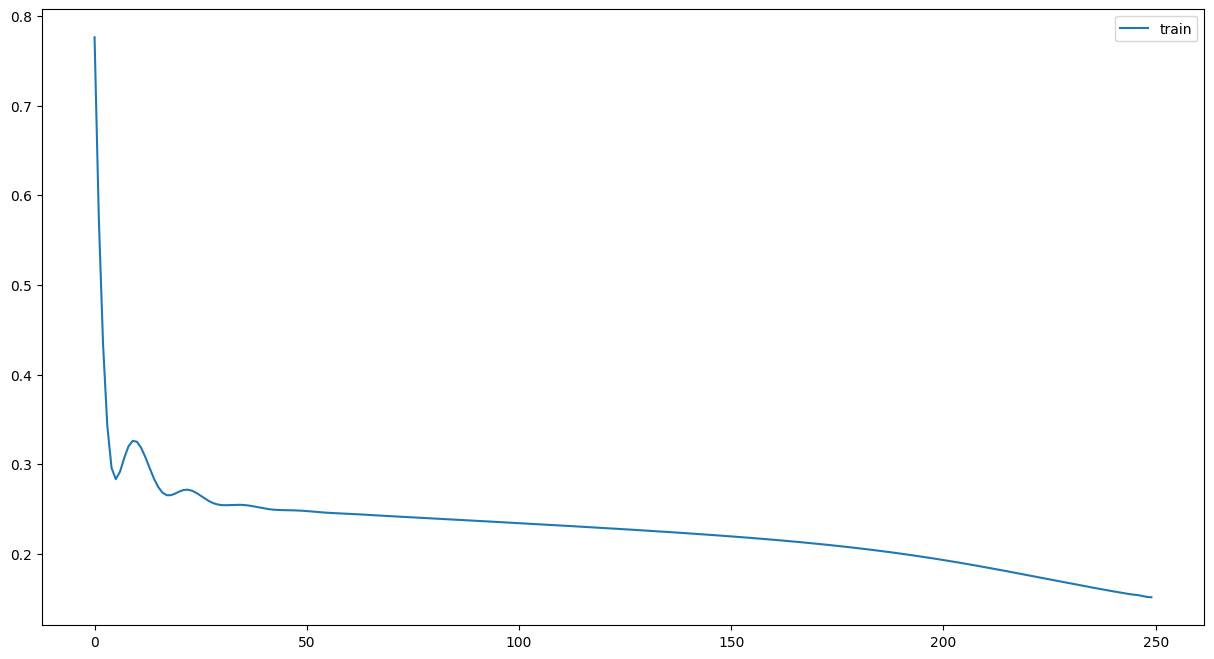

In [109]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(figsize=(15, 8))

axs.plot(range(250), train_losses_m1, label="train")
axs.legend()

In [110]:
# Evaluación training set
model1.eval()
all_preds_m1, all_labels_m1 = [], []
with torch.no_grad():
    for window in train_windows:
        data = torch_geo_graphs_unsw1_proto[window].to(device)
        out,emb_t = model1(data)
        probabilities = torch.sigmoid(out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_preds_m1.extend(preds)
        all_labels_m1.extend(data.y.cpu().numpy())

# Metrics
roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
accuracy_m1 = accuracy_score(all_labels_m1, all_preds_m1)
precision_m1 = precision_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m1 = recall_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)
f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m1:.4f}")
print(f"Accuracy: {accuracy_m1:.4f}")
print(f"Precision: {precision_m1:.4f}")
print(f"Recall: {recall_m1:.4f}")
print(f"F1: {f1_m1:.4f}")



ROC-AUC: 0.6079
Accuracy: 0.9115
Precision: 0.5852
Recall: 0.2330
F1: 0.3333


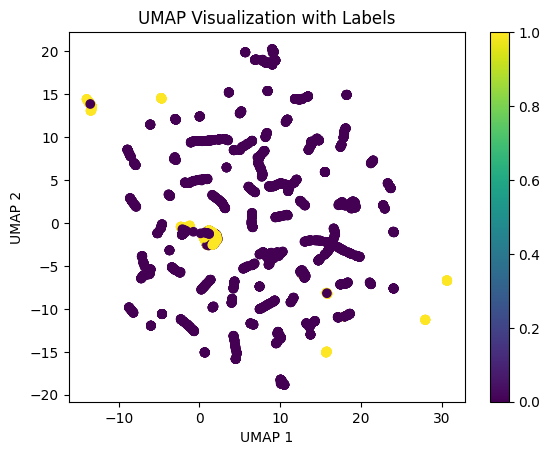

In [111]:
X = emb_t
y = torch_geo_graphs_unsw1_proto[18].y

umap_model = umap.UMAP(n_components=2)
umap_result = umap_model.fit_transform(X)

plt.scatter(umap_result[:, 0], umap_result[:, 1], c=y, cmap='viridis')
plt.colorbar()
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP Visualization with Labels')
plt.show()

## Training with 2 graphs (traditional - normalize features)

In [114]:
torch_geo_graphs_unsw1_proto[1]

Data(x=[4843, 4], edge_index=[2, 3532], edge_attr=[3532, 1], y=[3532])

In [115]:
torch_geo_graphs_unsw1_proto[18]

Data(x=[5354, 4], edge_index=[2, 3572], edge_attr=[3572, 1], y=[3572])

In [118]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

model1 = GNN_traditional_normalize(node_input_dim=4, edge_input_dim=1, hidden_dim1=32, hidden_dim2=16).to(device)
optimizer = torch.optim.Adam(model1.parameters(), lr=0.01)

#scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, verbose=True)


#ratio_neg_to_pos = 2
#pos_weight = torch.tensor([ratio_neg_to_pos], dtype=torch.float32).to(device)
criterion = torch.nn.BCEWithLogitsLoss()#pos_weight=pos_weight)


train_windows = [18] #list(range(28)) #30
#val_windows = list(range(31,36))#28,36)) #30,39


# Train
epochs = 250
train_losses_m1 = []
val_losses_m1 = []

for epoch in range(epochs):
    # ===== Training =====
    model1.train()
    epoch_loss = 0
    total_edges = 0
    # all_preds_m1, all_labels_m1 = [], []
    for window in train_windows:
        data = torch_geo_graphs_unsw1_proto[window].to(device)
        optimizer.zero_grad()
        out,_ = model1(data)
        loss = criterion(out.squeeze(), data.y.to(device).float()) # convert to float
        # probabilities = torch.sigmoid(out)
        # preds = (probabilities.view(-1) > 0.5).long()
        loss.backward()
        optimizer.step()
        # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
        #epoch_loss += loss.item()
        num_edges = data.y.size(0)
        epoch_loss += loss.item() * num_edges
        total_edges += num_edges
        # all_preds_m1.extend(preds)
        # all_labels_m1.extend(data.y.cpu().numpy())
    #train_loss = epoch_loss / len(train_windows)
    train_loss = epoch_loss / total_edges
    train_losses_m1.append(train_loss)
    # roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
    # f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

    # ===== Validation =====
    # model1.eval()
    # val_loss = 0
    # total_val_edges = 0
    # all_preds_m1, all_labels_m1 = [], []
    # with torch.no_grad():
    #     for window in val_windows:
    #         data = torch_geo_graphs_unsw1_proto[window].to(device)
    #         out = model1(data)
    #         loss = criterion(out.squeeze(), data.y.to(device).float())
    #         probabilities = torch.sigmoid(out)
    #         preds = (probabilities.view(-1) > 0.4).long()
    #         # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
    #         num_edges = data.y.size(0)
    #         val_loss += loss.item() * num_edges
    #         total_val_edges += num_edges
    #         all_preds_m1.extend(preds)
    #         all_labels_m1.extend(data.y.cpu().numpy())
    # val_loss_final = val_loss / total_val_edges #len(val_windows)
    # val_losses_m1.append(val_loss_final)
    # roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
    # f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

    # # Actualizar el scheduler
    # scheduler.step(f1_m1)

    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}")#, Val Loss: {val_loss_final:.4f}, , Current LR: {optimizer.param_groups[0]['lr']:.6f}, ROC-AUC: {roc_auc_m1}, F1:{f1_m1}")



Epoch 1/250, Train Loss: 0.6578
Epoch 2/250, Train Loss: 0.4878
Epoch 3/250, Train Loss: 0.3771
Epoch 4/250, Train Loss: 0.3163
Epoch 5/250, Train Loss: 0.2974
Epoch 6/250, Train Loss: 0.3055
Epoch 7/250, Train Loss: 0.3221
Epoch 8/250, Train Loss: 0.3343
Epoch 9/250, Train Loss: 0.3379
Epoch 10/250, Train Loss: 0.3334
Epoch 11/250, Train Loss: 0.3233
Epoch 12/250, Train Loss: 0.3104
Epoch 13/250, Train Loss: 0.2976
Epoch 14/250, Train Loss: 0.2873
Epoch 15/250, Train Loss: 0.2809
Epoch 16/250, Train Loss: 0.2789
Epoch 17/250, Train Loss: 0.2803
Epoch 18/250, Train Loss: 0.2832
Epoch 19/250, Train Loss: 0.2853
Epoch 20/250, Train Loss: 0.2852
Epoch 21/250, Train Loss: 0.2826
Epoch 22/250, Train Loss: 0.2785
Epoch 23/250, Train Loss: 0.2739
Epoch 24/250, Train Loss: 0.2699
Epoch 25/250, Train Loss: 0.2669
Epoch 26/250, Train Loss: 0.2652
Epoch 27/250, Train Loss: 0.2644
Epoch 28/250, Train Loss: 0.2643
Epoch 29/250, Train Loss: 0.2644
Epoch 30/250, Train Loss: 0.2644
Epoch 31/250, Train

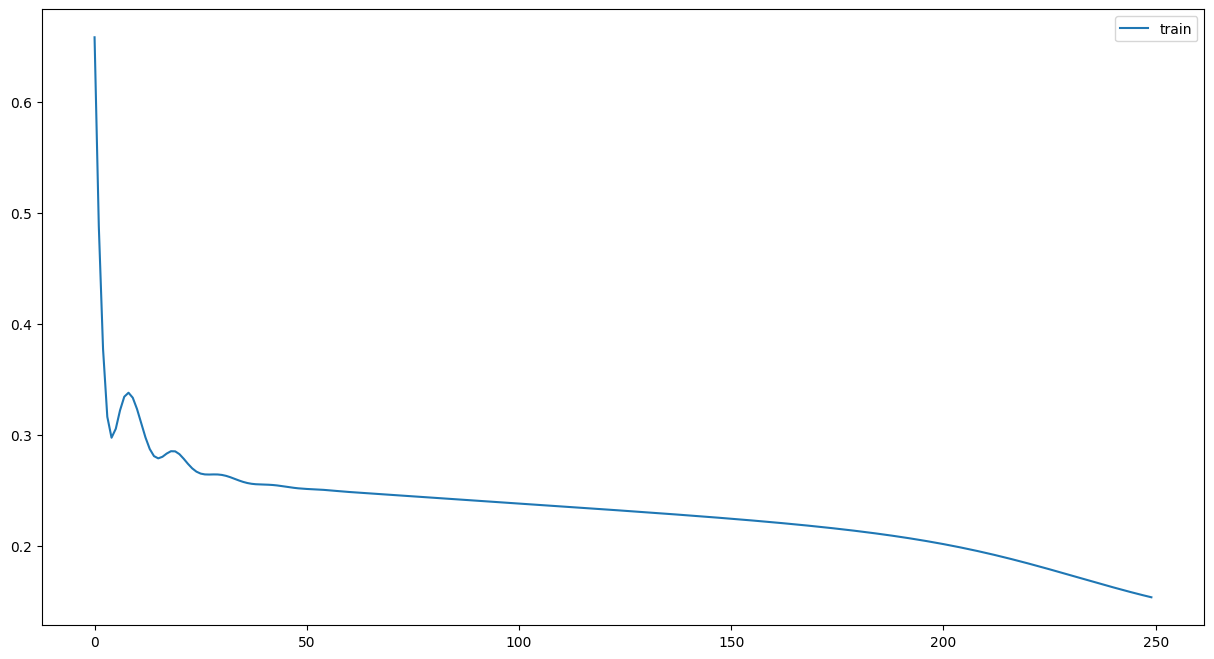

In [119]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(figsize=(15, 8))

axs.plot(range(250), train_losses_m1, label="train")
axs.legend()

In [120]:
# Evaluación training set
model1.eval()
all_preds_m1, all_labels_m1 = [], []
with torch.no_grad():
    for window in train_windows:
        data = torch_geo_graphs_unsw1_proto[window].to(device)
        out,emb_t = model1(data)
        probabilities = torch.sigmoid(out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_preds_m1.extend(preds)
        all_labels_m1.extend(data.y.cpu().numpy())

# Metrics
roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
accuracy_m1 = accuracy_score(all_labels_m1, all_preds_m1)
precision_m1 = precision_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m1 = recall_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)
f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m1:.4f}")
print(f"Accuracy: {accuracy_m1:.4f}")
print(f"Precision: {precision_m1:.4f}")
print(f"Recall: {recall_m1:.4f}")
print(f"F1: {f1_m1:.4f}")



ROC-AUC: 0.6208
Accuracy: 0.9135
Precision: 0.6027
Recall: 0.2596
F1: 0.3629


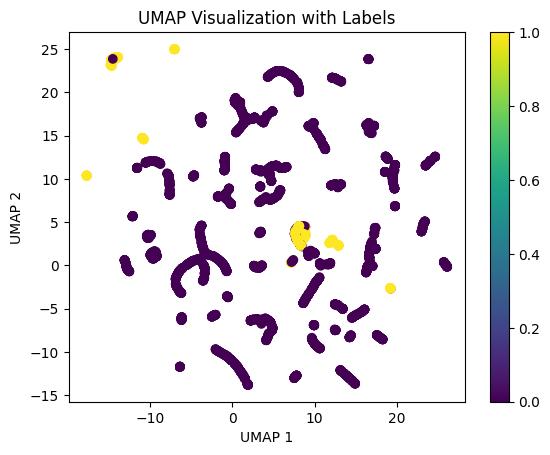

In [121]:
X = emb_t
y = torch_geo_graphs_unsw1_proto[18].y

umap_model = umap.UMAP(n_components=2)
umap_result = umap_model.fit_transform(X)

plt.scatter(umap_result[:, 0], umap_result[:, 1], c=y, cmap='viridis')
plt.colorbar()
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP Visualization with Labels')
plt.show()

## Training with 2 graphs (traditional - more features normalized)

In [124]:
torch_geo_graphs_unsw1_proto_more[1]

Data(x=[4843, 14], edge_index=[2, 3532], edge_attr=[3532, 3], y=[3532])

In [125]:
torch_geo_graphs_unsw1_proto_more[18]

Data(x=[5354, 14], edge_index=[2, 3572], edge_attr=[3572, 3], y=[3572])

In [127]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

model1 = GNN_traditional_normalize(node_input_dim=14, edge_input_dim=3, hidden_dim1=32, hidden_dim2=16).to(device)
optimizer = torch.optim.Adam(model1.parameters(), lr=0.01)

#scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, verbose=True)


#ratio_neg_to_pos = 2
#pos_weight = torch.tensor([ratio_neg_to_pos], dtype=torch.float32).to(device)
criterion = torch.nn.BCEWithLogitsLoss()#pos_weight=pos_weight)


train_windows = [18] #list(range(28)) #30
#val_windows = list(range(31,36))#28,36)) #30,39


# Train
epochs = 250
train_losses_m1 = []
val_losses_m1 = []

for epoch in range(epochs):
    # ===== Training =====
    model1.train()
    epoch_loss = 0
    total_edges = 0
    # all_preds_m1, all_labels_m1 = [], []
    for window in train_windows:
        data = torch_geo_graphs_unsw1_proto_more[window].to(device)
        optimizer.zero_grad()
        out,_ = model1(data)
        loss = criterion(out.squeeze(), data.y.to(device).float()) # convert to float
        # probabilities = torch.sigmoid(out)
        # preds = (probabilities.view(-1) > 0.5).long()
        loss.backward()
        optimizer.step()
        # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
        #epoch_loss += loss.item()
        num_edges = data.y.size(0)
        epoch_loss += loss.item() * num_edges
        total_edges += num_edges
        # all_preds_m1.extend(preds)
        # all_labels_m1.extend(data.y.cpu().numpy())
    #train_loss = epoch_loss / len(train_windows)
    train_loss = epoch_loss / total_edges
    train_losses_m1.append(train_loss)
    # roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
    # f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

    # ===== Validation =====
    # model1.eval()
    # val_loss = 0
    # total_val_edges = 0
    # all_preds_m1, all_labels_m1 = [], []
    # with torch.no_grad():
    #     for window in val_windows:
    #         data = torch_geo_graphs_unsw1_proto[window].to(device)
    #         out = model1(data)
    #         loss = criterion(out.squeeze(), data.y.to(device).float())
    #         probabilities = torch.sigmoid(out)
    #         preds = (probabilities.view(-1) > 0.4).long()
    #         # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
    #         num_edges = data.y.size(0)
    #         val_loss += loss.item() * num_edges
    #         total_val_edges += num_edges
    #         all_preds_m1.extend(preds)
    #         all_labels_m1.extend(data.y.cpu().numpy())
    # val_loss_final = val_loss / total_val_edges #len(val_windows)
    # val_losses_m1.append(val_loss_final)
    # roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
    # f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

    # # Actualizar el scheduler
    # scheduler.step(f1_m1)

    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}")#, Val Loss: {val_loss_final:.4f}, , Current LR: {optimizer.param_groups[0]['lr']:.6f}, ROC-AUC: {roc_auc_m1}, F1:{f1_m1}")



Epoch 1/250, Train Loss: 0.7936
Epoch 2/250, Train Loss: 0.6695
Epoch 3/250, Train Loss: 0.5633
Epoch 4/250, Train Loss: 0.4700
Epoch 5/250, Train Loss: 0.3917
Epoch 6/250, Train Loss: 0.3322
Epoch 7/250, Train Loss: 0.2938
Epoch 8/250, Train Loss: 0.2741
Epoch 9/250, Train Loss: 0.2657
Epoch 10/250, Train Loss: 0.2606
Epoch 11/250, Train Loss: 0.2523
Epoch 12/250, Train Loss: 0.2383
Epoch 13/250, Train Loss: 0.2186
Epoch 14/250, Train Loss: 0.1952
Epoch 15/250, Train Loss: 0.1709
Epoch 16/250, Train Loss: 0.1487
Epoch 17/250, Train Loss: 0.1312
Epoch 18/250, Train Loss: 0.1194
Epoch 19/250, Train Loss: 0.1130
Epoch 20/250, Train Loss: 0.1106
Epoch 21/250, Train Loss: 0.1105
Epoch 22/250, Train Loss: 0.1109
Epoch 23/250, Train Loss: 0.1106
Epoch 24/250, Train Loss: 0.1092
Epoch 25/250, Train Loss: 0.1064
Epoch 26/250, Train Loss: 0.1027
Epoch 27/250, Train Loss: 0.0982
Epoch 28/250, Train Loss: 0.0933
Epoch 29/250, Train Loss: 0.0885
Epoch 30/250, Train Loss: 0.0839
Epoch 31/250, Train

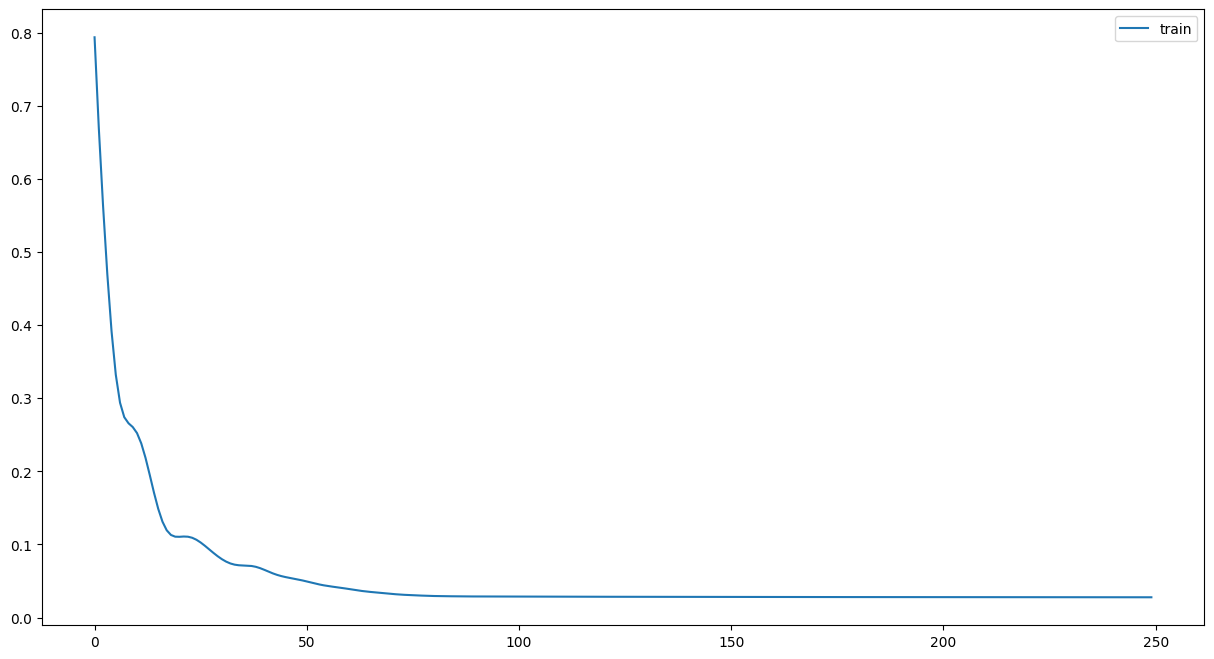

In [128]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(figsize=(15, 8))

axs.plot(range(250), train_losses_m1, label="train")
axs.legend()

In [129]:
# Evaluación training set
model1.eval()
all_preds_m1, all_labels_m1 = [], []
with torch.no_grad():
    for window in train_windows:
        data = torch_geo_graphs_unsw1_proto_more[window].to(device)
        out,emb_t = model1(data)
        probabilities = torch.sigmoid(out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_preds_m1.extend(preds)
        all_labels_m1.extend(data.y.cpu().numpy())

# Metrics
roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
accuracy_m1 = accuracy_score(all_labels_m1, all_preds_m1)
precision_m1 = precision_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m1 = recall_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)
f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m1:.4f}")
print(f"Accuracy: {accuracy_m1:.4f}")
print(f"Precision: {precision_m1:.4f}")
print(f"Recall: {recall_m1:.4f}")
print(f"F1: {f1_m1:.4f}")



ROC-AUC: 0.9607
Accuracy: 0.9910
Precision: 0.9812
Recall: 0.9233
F1: 0.9514


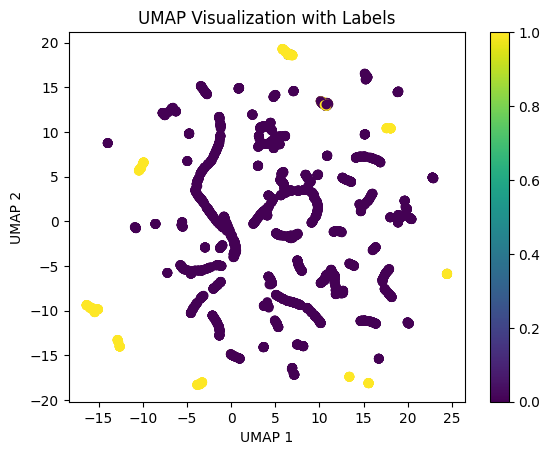

In [131]:
X = emb_t
y = torch_geo_graphs_unsw1_proto_more[18].y

umap_model = umap.UMAP(n_components=2)
umap_result = umap_model.fit_transform(X)

plt.scatter(umap_result[:, 0], umap_result[:, 1], c=y, cmap='viridis')
plt.colorbar()
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP Visualization with Labels')
plt.show()

In [132]:
# Evaluación validation set
model1.eval()
all_preds_m1, all_labels_m1 = [], []
with torch.no_grad():
    for window in [1]:
        data = torch_geo_graphs_unsw1_proto_more[window].to(device)
        out,emb_v = model1(data)
        probabilities = torch.sigmoid(out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_preds_m1.extend(preds)
        all_labels_m1.extend(data.y.cpu().numpy())

# Metrics
roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
accuracy_m1 = accuracy_score(all_labels_m1, all_preds_m1)
precision_m1 = precision_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m1 = recall_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)
f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m1:.4f}")
print(f"Accuracy: {accuracy_m1:.4f}")
print(f"Precision: {precision_m1:.4f}")
print(f"Recall: {recall_m1:.4f}")
print(f"F1: {f1_m1:.4f}")



ROC-AUC: 0.9666
Accuracy: 0.9892
Precision: 0.9331
Recall: 0.9394
F1: 0.9362


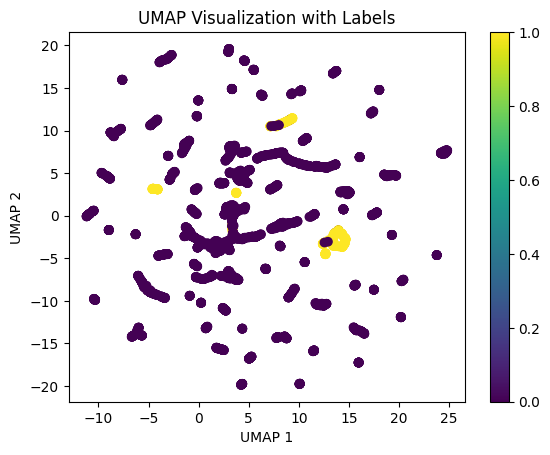

In [133]:
X = emb_v
y = torch_geo_graphs_unsw1_proto_more[1].y

umap_model = umap.UMAP(n_components=2)
umap_result = umap_model.fit_transform(X)

plt.scatter(umap_result[:, 0], umap_result[:, 1], c=y, cmap='viridis')
plt.colorbar()
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP Visualization with Labels')
plt.show()

## Model 1: traditional - normalize features

In [134]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

model1 = GNN_traditional_normalize(node_input_dim=4, edge_input_dim=1, hidden_dim1=32, hidden_dim2=16).to(device)
optimizer = torch.optim.Adam(model1.parameters(), lr=0.01)
#scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)


#ratio_neg_to_pos = 10
#pos_weight = torch.tensor([ratio_neg_to_pos], dtype=torch.float32).to(device)
criterion = torch.nn.BCEWithLogitsLoss()#pos_weight=pos_weight)


train_windows = list(range(28))
val_windows = list(range(31,36))#28,36))


# Train
epochs = 75
train_losses_m1 = []
val_losses_m1 = []

for epoch in range(epochs):
    # ===== Training =====
    model1.train()
    epoch_loss = 0
    total_edges = 0
    # all_preds_m1, all_labels_m1 = [], []
    for window in train_windows:
        data = torch_geo_graphs_unsw1_proto[window].to(device)
        optimizer.zero_grad()
        out,_ = model1(data)
        loss = criterion(out.squeeze(), data.y.to(device).float()) # convert to float
        # probabilities = torch.sigmoid(out)
        # preds = (probabilities.view(-1) > 0.5).long()
        loss.backward()
        optimizer.step()
        # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
        #epoch_loss += loss.item()
        num_edges = data.y.size(0)
        epoch_loss += loss.item() * num_edges
        total_edges += num_edges
        # all_preds_m1.extend(preds)
        # all_labels_m1.extend(data.y.cpu().numpy())
    #train_loss = epoch_loss / len(train_windows)
    train_loss = epoch_loss / total_edges
    train_losses_m1.append(train_loss)
    # roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
    # f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

    # ===== Validation =====
    model1.eval()
    val_loss = 0
    total_val_edges = 0
    all_preds_m1, all_labels_m1 = [], []
    with torch.no_grad():
        for window in val_windows:
            data = torch_geo_graphs_unsw1_proto[window].to(device)
            out,_ = model1(data)
            loss = criterion(out.squeeze(), data.y.to(device).float())
            probabilities = torch.sigmoid(out)
            preds = (probabilities.view(-1) > 0.4).long()
            # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
            num_edges = data.y.size(0)
            val_loss += loss.item() * num_edges
            total_val_edges += num_edges
            all_preds_m1.extend(preds)
            all_labels_m1.extend(data.y.cpu().numpy())
    val_loss_final = val_loss / total_val_edges #len(val_windows)
    val_losses_m1.append(val_loss_final)
    roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
    f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

    # Actualizar el scheduler
    scheduler.step(f1_m1)

    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss_final:.4f}, , Current LR: {optimizer.param_groups[0]['lr']:.6f}, ROC-AUC: {roc_auc_m1}, F1:{f1_m1}")



Epoch 1/75, Train Loss: 0.2642, Val Loss: 0.1822, , Current LR: 0.010000, ROC-AUC: 0.5, F1:0.0
Epoch 2/75, Train Loss: 0.1997, Val Loss: 0.1647, , Current LR: 0.010000, ROC-AUC: 0.5, F1:0.0
Epoch 3/75, Train Loss: 0.1913, Val Loss: 0.1577, , Current LR: 0.010000, ROC-AUC: 0.5, F1:0.0
Epoch 4/75, Train Loss: 0.1862, Val Loss: 0.1532, , Current LR: 0.010000, ROC-AUC: 0.5, F1:0.0
Epoch 5/75, Train Loss: 0.1823, Val Loss: 0.1499, , Current LR: 0.010000, ROC-AUC: 0.5, F1:0.0
Epoch 6/75, Train Loss: 0.1788, Val Loss: 0.1473, , Current LR: 0.010000, ROC-AUC: 0.5, F1:0.0
Epoch 7/75, Train Loss: 0.1754, Val Loss: 0.1449, , Current LR: 0.005000, ROC-AUC: 0.5, F1:0.0
Epoch 8/75, Train Loss: 0.1719, Val Loss: 0.1446, , Current LR: 0.005000, ROC-AUC: 0.5, F1:0.0
Epoch 9/75, Train Loss: 0.1705, Val Loss: 0.1436, , Current LR: 0.005000, ROC-AUC: 0.5, F1:0.0
Epoch 10/75, Train Loss: 0.1690, Val Loss: 0.1425, , Current LR: 0.005000, ROC-AUC: 0.5, F1:0.0
Epoch 11/75, Train Loss: 0.1675, Val Loss: 0.1414

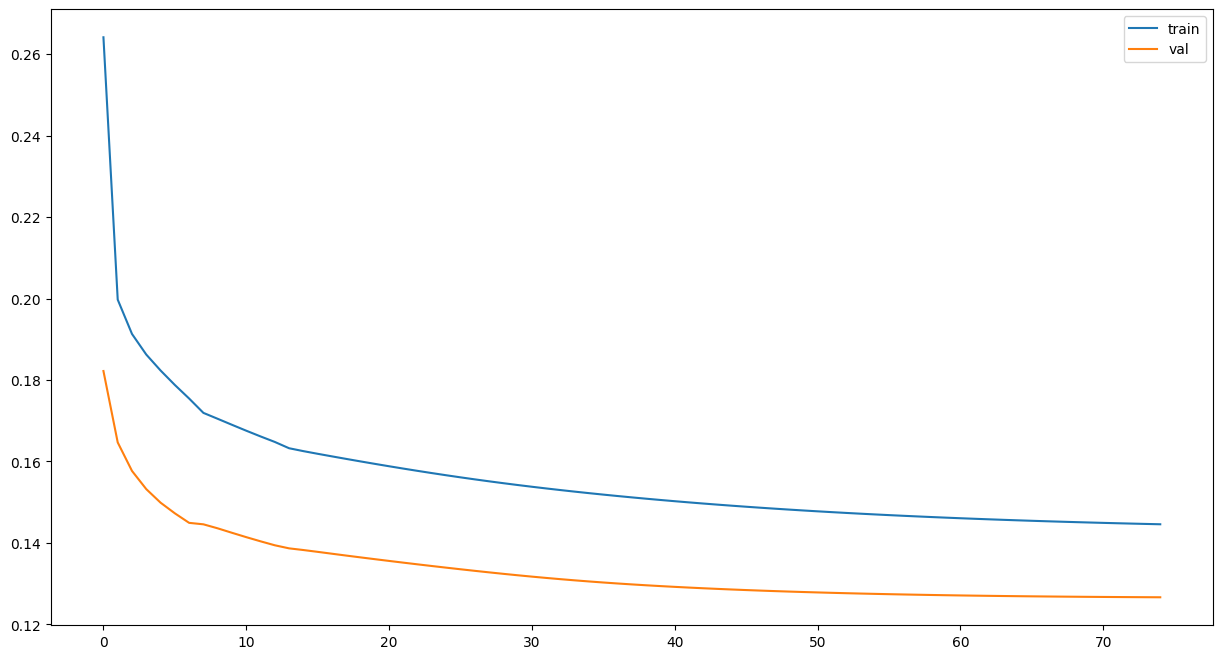

In [135]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(figsize=(15, 8))

axs.plot(range(75), train_losses_m1, label="train")
axs.plot(range(75), val_losses_m1, label="val")
axs.legend()

In [136]:
# Evaluación training set
model1.eval()
all_preds_m1, all_labels_m1 = [], []
embeddings_training = []
with torch.no_grad():
    for window in train_windows:
        data = torch_geo_graphs_unsw1_proto[window].to(device)
        out,emb_t = model1(data)
        probabilities = torch.sigmoid(out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_preds_m1.extend(preds)
        all_labels_m1.extend(data.y.cpu().numpy())
        embeddings_training.append(emb_t)

# Metrics
roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
accuracy_m1 = accuracy_score(all_labels_m1, all_preds_m1)
precision_m1 = precision_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m1 = recall_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)
f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m1:.4f}")
print(f"Accuracy: {accuracy_m1:.4f}")
print(f"Precision: {precision_m1:.4f}")
print(f"Recall: {recall_m1:.4f}")
print(f"F1: {f1_m1:.4f}")



ROC-AUC: 0.5479
Accuracy: 0.9452
Precision: 0.5128
Recall: 0.1015
F1: 0.1694


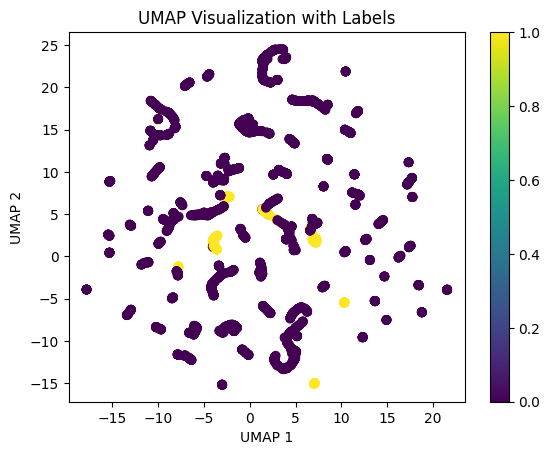

In [137]:
# Vemos un embedding a modo de ejemplo

X = embeddings_training[1]
y = torch_geo_graphs_unsw1_proto[1].y

umap_model = umap.UMAP(n_components=2)
umap_result = umap_model.fit_transform(X)

plt.scatter(umap_result[:, 0], umap_result[:, 1], c=y, cmap='viridis')
plt.colorbar()
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP Visualization with Labels')
plt.show()


In [138]:
# Evaluación validation set
model1.eval()
all_preds_m1, all_labels_m1 = [], []
with torch.no_grad():
    for window in val_windows:
        data = torch_geo_graphs_unsw1_proto[window].to(device)
        out,emb_v = model1(data)
        probabilities = torch.sigmoid(out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_preds_m1.extend(preds)
        all_labels_m1.extend(data.y.cpu().numpy())

# Metrics
roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
accuracy_m1 = accuracy_score(all_labels_m1, all_preds_m1)
precision_m1 = precision_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m1 = recall_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)
f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m1:.4f}")
print(f"Accuracy: {accuracy_m1:.4f}")
print(f"Precision: {precision_m1:.4f}")
print(f"Recall: {recall_m1:.4f}")
print(f"F1: {f1_m1:.4f}")



ROC-AUC: 0.5501
Accuracy: 0.9539
Precision: 0.4118
Recall: 0.1073
F1: 0.1702


## Model 1: traditional - more features normalized

In [140]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

model1 = GNN_traditional_normalize(node_input_dim=14, edge_input_dim=3, hidden_dim1=32, hidden_dim2=16).to(device)
optimizer = torch.optim.Adam(model1.parameters(), lr=0.01)
#scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)


#ratio_neg_to_pos = 10
#pos_weight = torch.tensor([ratio_neg_to_pos], dtype=torch.float32).to(device)
criterion = torch.nn.BCEWithLogitsLoss()#pos_weight=pos_weight)


train_windows = list(range(28))
val_windows = list(range(31,36))#28,36))


# Train
epochs = 15
train_losses_m1 = []
val_losses_m1 = []

for epoch in range(epochs):
    # ===== Training =====
    model1.train()
    epoch_loss = 0
    total_edges = 0
    # all_preds_m1, all_labels_m1 = [], []
    for window in train_windows:
        data = torch_geo_graphs_unsw1_proto_more[window].to(device)
        optimizer.zero_grad()
        out,_ = model1(data)
        loss = criterion(out.squeeze(), data.y.to(device).float()) # convert to float
        # probabilities = torch.sigmoid(out)
        # preds = (probabilities.view(-1) > 0.5).long()
        loss.backward()
        optimizer.step()
        # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
        #epoch_loss += loss.item()
        num_edges = data.y.size(0)
        epoch_loss += loss.item() * num_edges
        total_edges += num_edges
        # all_preds_m1.extend(preds)
        # all_labels_m1.extend(data.y.cpu().numpy())
    #train_loss = epoch_loss / len(train_windows)
    train_loss = epoch_loss / total_edges
    train_losses_m1.append(train_loss)
    # roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
    # f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

    # ===== Validation =====
    model1.eval()
    val_loss = 0
    total_val_edges = 0
    all_preds_m1, all_labels_m1 = [], []
    with torch.no_grad():
        for window in val_windows:
            data = torch_geo_graphs_unsw1_proto_more[window].to(device)
            out,_ = model1(data)
            loss = criterion(out.squeeze(), data.y.to(device).float())
            probabilities = torch.sigmoid(out)
            preds = (probabilities.view(-1) > 0.4).long()
            # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
            num_edges = data.y.size(0)
            val_loss += loss.item() * num_edges
            total_val_edges += num_edges
            all_preds_m1.extend(preds)
            all_labels_m1.extend(data.y.cpu().numpy())
    val_loss_final = val_loss / total_val_edges #len(val_windows)
    val_losses_m1.append(val_loss_final)
    roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
    f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

    # Actualizar el scheduler
    scheduler.step(f1_m1)

    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss_final:.4f}, , Current LR: {optimizer.param_groups[0]['lr']:.6f}, ROC-AUC: {roc_auc_m1}, F1:{f1_m1}")



Epoch 1/15, Train Loss: 0.2234, Val Loss: 0.1037, , Current LR: 0.010000, ROC-AUC: 0.9543011571409138, F1:0.6604609929078015
Epoch 2/15, Train Loss: 0.0924, Val Loss: 0.0828, , Current LR: 0.010000, ROC-AUC: 0.9335522134710776, F1:0.64376130198915
Epoch 3/15, Train Loss: 0.0781, Val Loss: 0.0731, , Current LR: 0.010000, ROC-AUC: 0.9379277857979683, F1:0.7036669970267592
Epoch 4/15, Train Loss: 0.0687, Val Loss: 0.0663, , Current LR: 0.010000, ROC-AUC: 0.8506731884013831, F1:0.6758538046734571
Epoch 5/15, Train Loss: 0.0605, Val Loss: 0.0622, , Current LR: 0.010000, ROC-AUC: 0.8121711975667352, F1:0.6394904458598726
Epoch 6/15, Train Loss: 0.0568, Val Loss: 0.0617, , Current LR: 0.010000, ROC-AUC: 0.7916466161902267, F1:0.6340801086218602
Epoch 7/15, Train Loss: 0.0556, Val Loss: 0.0615, , Current LR: 0.010000, ROC-AUC: 0.7848081347067147, F1:0.6350314026517795
Epoch 8/15, Train Loss: 0.0550, Val Loss: 0.0612, , Current LR: 0.010000, ROC-AUC: 0.7882365123744435, F1:0.6433566433566433
Ep

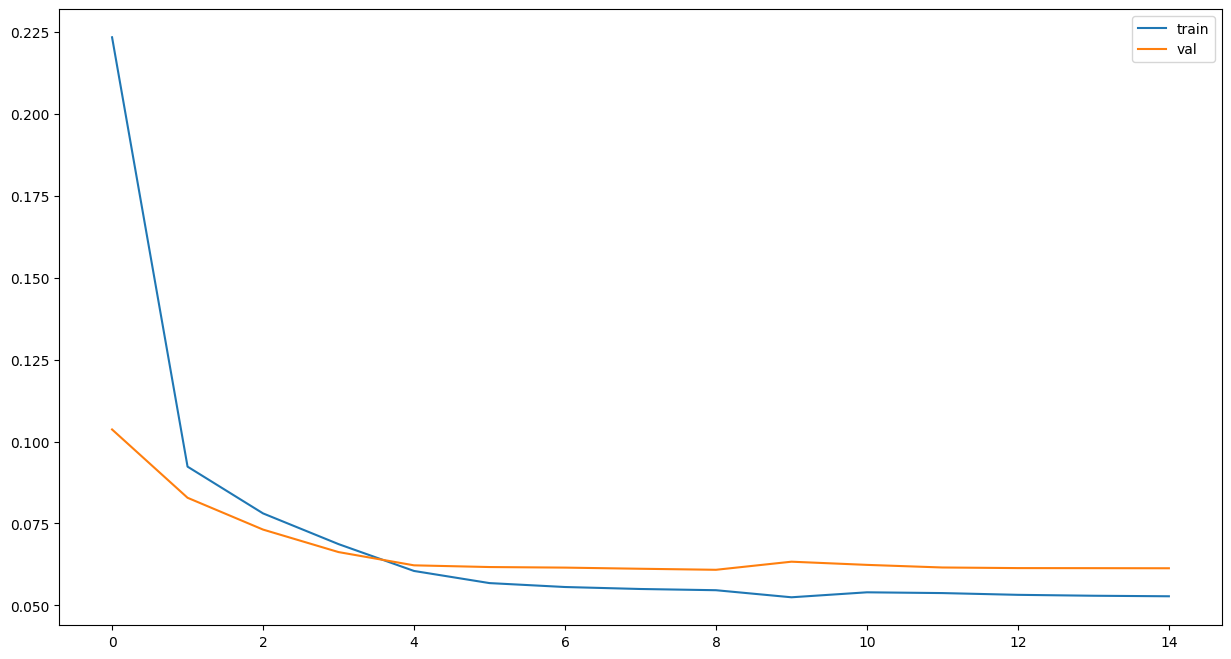

In [142]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(figsize=(15, 8))

axs.plot(range(15), train_losses_m1, label="train")
axs.plot(range(15), val_losses_m1, label="val")
axs.legend()

In [143]:
# Evaluación training set
model1.eval()
all_preds_m1, all_labels_m1 = [], []
embeddings_training = []
with torch.no_grad():
    for window in train_windows:
        data = torch_geo_graphs_unsw1_proto_more[window].to(device)
        out,emb_t = model1(data)
        probabilities = torch.sigmoid(out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_preds_m1.extend(preds)
        all_labels_m1.extend(data.y.cpu().numpy())
        embeddings_training.append(emb_t)

# Metrics
roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
accuracy_m1 = accuracy_score(all_labels_m1, all_preds_m1)
precision_m1 = precision_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m1 = recall_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)
f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m1:.4f}")
print(f"Accuracy: {accuracy_m1:.4f}")
print(f"Precision: {precision_m1:.4f}")
print(f"Recall: {recall_m1:.4f}")
print(f"F1: {f1_m1:.4f}")

# ROC-AUC: 0.8967
# Accuracy: 0.9792
# Precision: 0.8152
# Recall: 0.8040
# F1: 0.8095

ROC-AUC: 0.8949
Accuracy: 0.9760
Precision: 0.7708
Recall: 0.8038
F1: 0.7869


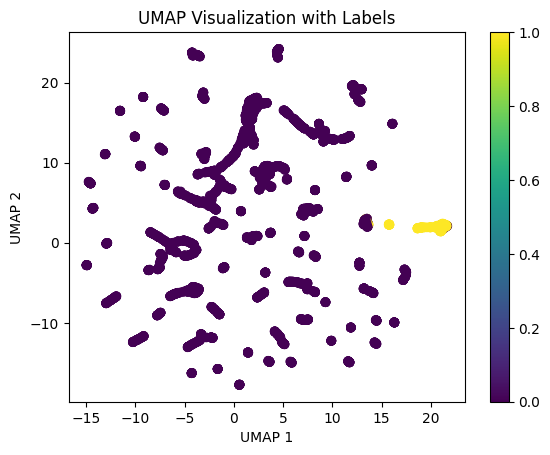

In [146]:
# Vemos un embedding a modo de ejemplo


X = embeddings_training[2]
y = torch_geo_graphs_unsw1_proto[2].y

umap_model = umap.UMAP(n_components=2)
umap_result = umap_model.fit_transform(X)

plt.scatter(umap_result[:, 0], umap_result[:, 1], c=y, cmap='viridis')
plt.colorbar()
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP Visualization with Labels')
plt.show()


In [145]:
# Evaluación validation set
model1.eval()
all_preds_m1, all_labels_m1 = [], []
with torch.no_grad():
    for window in val_windows:
        data = torch_geo_graphs_unsw1_proto_more[window].to(device)
        out,emb_v = model1(data)
        probabilities = torch.sigmoid(out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_preds_m1.extend(preds)
        all_labels_m1.extend(data.y.cpu().numpy())

# Metrics
roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
accuracy_m1 = accuracy_score(all_labels_m1, all_preds_m1)
precision_m1 = precision_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m1 = recall_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)
f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m1:.4f}")
print(f"Accuracy: {accuracy_m1:.4f}")
print(f"Precision: {precision_m1:.4f}")
print(f"Recall: {recall_m1:.4f}")
print(f"F1: {f1_m1:.4f}")



ROC-AUC: 0.8116
Accuracy: 0.9729
Precision: 0.7172
Recall: 0.6347
F1: 0.6734
